# Figure 1

Params: 

$\lambda_0 = 900 $ nm, 

$\alpha = 25 $ deg, 

$\psi = \pi/2$, 

$\chi=\pi/8$, 

$d=2$ nm, 

$R=[100,165]$ nm

## Scattering cross section from $\lambda$, R=147.5 nm

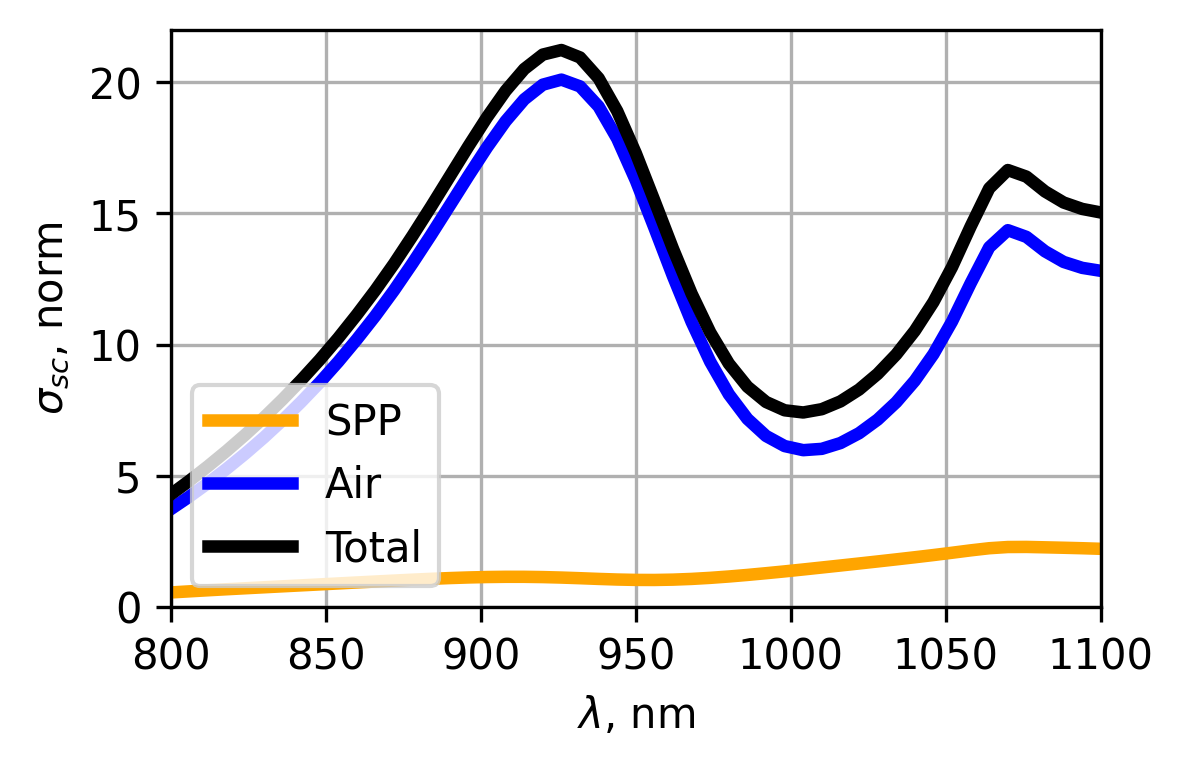

In [1]:
import numpy as np
import matplotlib.pyplot as plt

sigma_sc = np.loadtxt('article_data_plots/sigma_air_sigma_sc_wl_295nm_circ_pol.txt', skiprows=0, delimiter=',')

plt.figure(figsize=(4,2.5), dpi=300)
plt.plot(sigma_sc[:,0], sigma_sc[:,2], label='SPP', color='orange', lw=3)
plt.plot(sigma_sc[:,0], sigma_sc[:,1], label='Air', color='blue', lw=3)
plt.plot(sigma_sc[:,0], sigma_sc[:,1]+sigma_sc[:,2], label='Total', lw=3, c='black')
plt.ylabel(r'$\sigma_{sc}$, norm')
plt.xlabel('$\\lambda$, nm')
plt.grid()
plt.legend(loc='lower left')
plt.xlim(sigma_sc[0,0], sigma_sc[-1,0])
plt.ylim(0,22)
#plt.savefig('article_plots/scat_sc_air_spp.svg', bbox_inches='tight')
plt.show()

## Scattering cross section from R, $\lambda=900$ nm

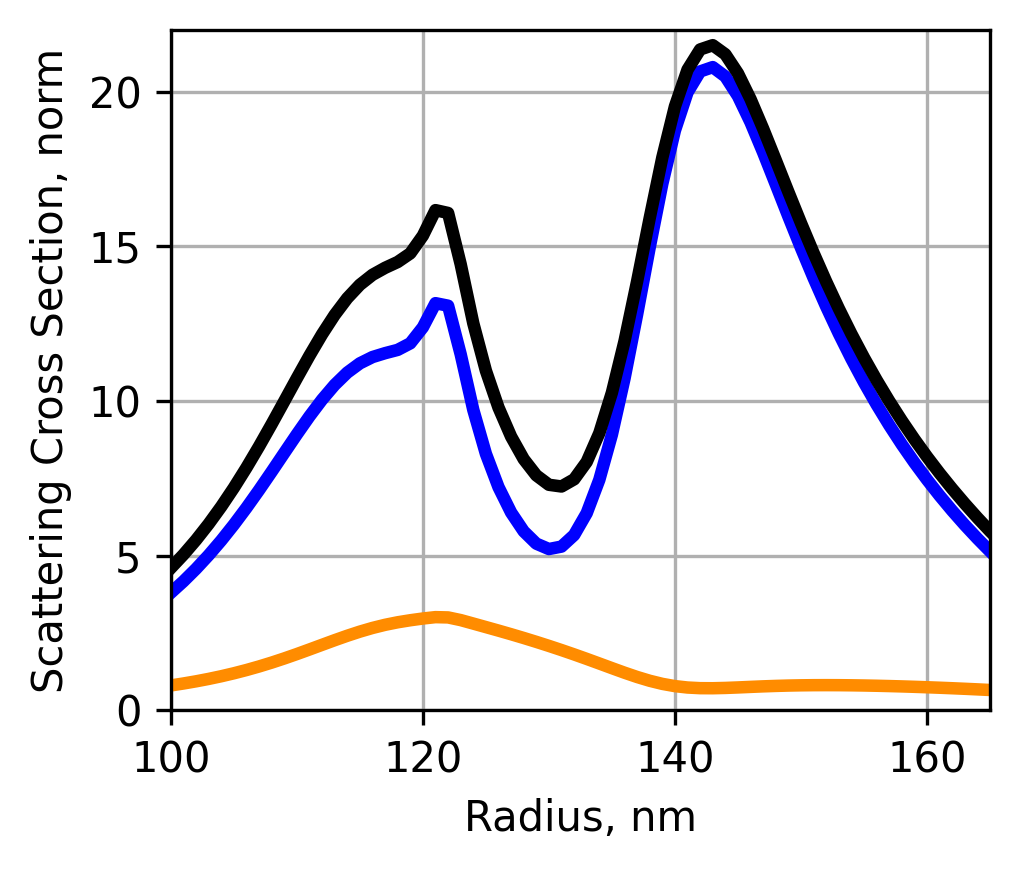

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False


sigma_sc = np.loadtxt('article_data_plots/sigma_air_sigma_sc_R_900nm_circ_pol.txt', skiprows=0, delimiter=',')

fig = plt.figure(figsize=(3.5, 3), dpi=300)

# делаем GridSpec такой же, но второй столбец пустой
# gs = GridSpec(1, 2, width_ratios=[20, 1], wspace=0.05)

# ax = fig.add_subplot(gs[0]) 

ax = fig.add_subplot(1, 1, 1)

ax.plot(sigma_sc[:,0], sigma_sc[:,2]/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='SPP', color='darkorange', lw=3)
ax.plot(sigma_sc[:,0], sigma_sc[:,1]/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='Air', color='blue', lw=3)
ax.plot(sigma_sc[:,0], (sigma_sc[:,1]+sigma_sc[:,2])/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='Total', lw=3, c='black')

# plt.plot(sigma_sc[:,0], (sigma_sc[:,1]+sigma_sc[:,2])/(np.pi*(sigma_sc[:,0]*1e-9)**2), label='numerical', lw=3, c='black', ls='--')

# plt.plot(R, (sigma_MD+sigma_ED)/(np.pi*(R*1e-9)**2), label='analytical', color='black', lw=3)

# ax.set_ylabel(r'$\sigma_{sc}$, norm')
ax.set_ylabel('Scattering Cross Section, norm')
ax.set_xlabel('Radius, nm')
ax.grid()
# ax.legend(loc='upper right')
ax.set_xlim(100,165)
plt.tight_layout()
plt.ylim(0,22)
plt.savefig('article_plots/figure 1/sc_cs_air_spp_raw.svg', format="svg"
            # bbox_inches='tight', 
            # dpi=300
            )
plt.show()

## 3D plot check in `3D_plot.ipynb`

## SPP Heatmap

In [2]:
from MieSppForce.simulation import SimulationConfig, SweepRunner,  DipoleCalculator, OpticalForceCalculator, DiagramCalculator, CylindricalGrid, SphericalGrid, DiagramResult, ureg
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
import numpy as np
from pint import UnitRegistry



def get_mean_angle(I, phi):
    vec_sum = np.sum(I * np.exp(1j * phi))
    return np.angle(vec_sum)
    
def get_maximum_direction(diag):
    import numpy as np
    from scipy.spatial import ConvexHull

    n = np.column_stack([
        np.sin(diag.theta) * np.cos(diag.phi),
        np.sin(diag.theta) * np.sin(diag.phi),
        np.cos(diag.theta)
    ])

    hull = ConvexHull(n)
    dOmega = np.zeros(len(n))

    for tri in hull.simplices:
        a, b, c = n[tri]
        num = abs(np.dot(a, np.cross(b, c)))
        den = 1 + np.dot(a, b) + np.dot(b, c) + np.dot(c, a)
        Omega = 2 * np.arctan2(num, den)
        dOmega[tri] += Omega / 3

    Px = np.sum(diag.D * n[:, 0] * dOmega)
    Py = np.sum(diag.D * n[:, 1] * dOmega)
    Pz = np.sum(diag.D * n[:, 2] * dOmega)

    phi_eff = np.arctan2(Py, Px)
    theta_eff = np.arctan2(np.sqrt(Px ** 2 + Py ** 2), Pz)
    return theta_eff, phi_eff


base_config = SimulationConfig(
    wl = 900 * ureg.nanometer,
    R =  130 * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(25),
    psi = np.pi/2,
    chi = np.pi/4,
    show_warnings=False,
    initial_field_type='plane_wave',
    amplitude=3*1e7
)

num_points = 100

XOY_SPP = CylindricalGrid(phi=np.linspace(0, 2*np.pi, 100)*ureg.rad, 
                          z=0*ureg.nm, 
                          r=base_config.wl*5)

XOY_AIR = SphericalGrid(
    r= base_config.wl,
    theta = np.linspace(0, np.pi/2, 20) * ureg.rad,
    phi = np.linspace(0, 2*np.pi, 100) * ureg.rad
)

dipoles = DipoleCalculator(base_config).compute()

In [2]:
base_config_scheme = SimulationConfig(
    wl=900*ureg.nm,
    #     R = 110.5*ureg.nm,
    R=130*ureg.nm,
    dist=2 * ureg.nm,
    angle=np.deg2rad(25),
    psi=np.deg2rad(45),
    chi=np.deg2rad(22.5),
    substrate='Au',
    particle='Si',
    show_warnings=True,
    initial_field_type='plane_wave'
)

XOZ_scheme = SphericalGrid(
    r= base_config_scheme.wl,
    theta = np.linspace(-np.pi/2, np.pi/2, 200) * ureg.rad,
    phi = 0 * ureg.rad
)

YOZ_scheme = SphericalGrid(
    r= base_config_scheme.wl,
    theta = np.linspace(-np.pi/2, np.pi/2, 200) * ureg.rad,
    phi = np.pi/2 * ureg.rad
)

I0 = base_config_scheme.c_const*base_config_scheme.eps0_const/2 
I0 = I0.magnitude

diagTotXOZ = DiagramCalculator(base_config_scheme, XOZ_scheme, normalize=None).compute()
diagRegXOZ = DiagramCalculator(base_config_scheme, XOZ_scheme, normalize=None).compute('reg')
diagSppXOZ = DiagramCalculator(base_config_scheme, XOZ_scheme, normalize=None).compute('spp')
diagMixXOZ = DiagramResult(diagTotXOZ.phi, diagTotXOZ.theta, diagTotXOZ.D - diagRegXOZ.D - diagSppXOZ.D ) 

diagTotYOZ = DiagramCalculator(base_config_scheme, YOZ_scheme, normalize=None).compute()
diagRegYOZ = DiagramCalculator(base_config_scheme, YOZ_scheme, normalize=None).compute('reg')
diagSppYOZ = DiagramCalculator(base_config_scheme, YOZ_scheme, normalize=None).compute('spp')
diagMixYOZ = DiagramResult(diagTotYOZ.phi, diagTotYOZ.theta, diagTotYOZ.D - diagRegYOZ.D - diagSppYOZ.D ) 

  0%|          | 1/200 [00:00<01:01,  3.26it/s]/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:442: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  re_retval = quad(refunc, a, b, args, full_output, epsabs,
 12%|█▎        | 25/200 [00:07<00:51,  3.42it/s]


KeyboardInterrupt: 

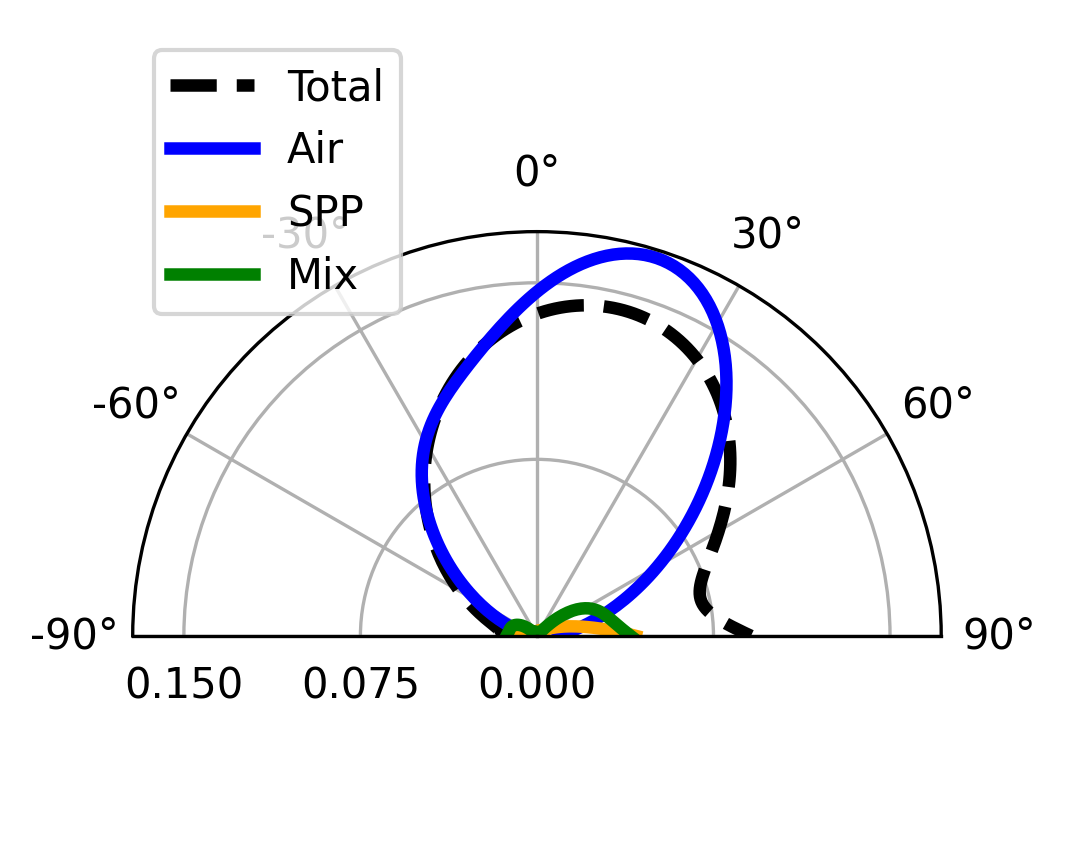

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(3.5,3.5), dpi=300)
ax = fig.add_subplot(111, projection='polar')

ax.plot(diagTotXOZ.theta, diagTotXOZ.D/I0, label='Total', color='black', lw=3, ls='--')
ax.plot(diagRegXOZ.theta, diagRegXOZ.D/I0, label='Air',   color='blue',  lw=3)
ax.plot(diagSppXOZ.theta, diagSppXOZ.D/I0, label='SPP',   color='orange',lw=3)
ax.plot(diagMixXOZ.theta, diagMixXOZ.D/I0, label='Mix',   color='green', lw=3)

ax.set_xlim(-np.pi, np.pi)
ax.set_theta_direction(-1)
ax.set_theta_zero_location("N") 
ax.legend()
ax.set_thetamin(-90)
ax.set_thetamax(90)

ax.set_ylim(0, np.max(diagTotXOZ.D/I0)*1.2)
ax.set_yticks([0, 0.075, .15])

#ax.set_ylabel('Diagram D')
plt.show()

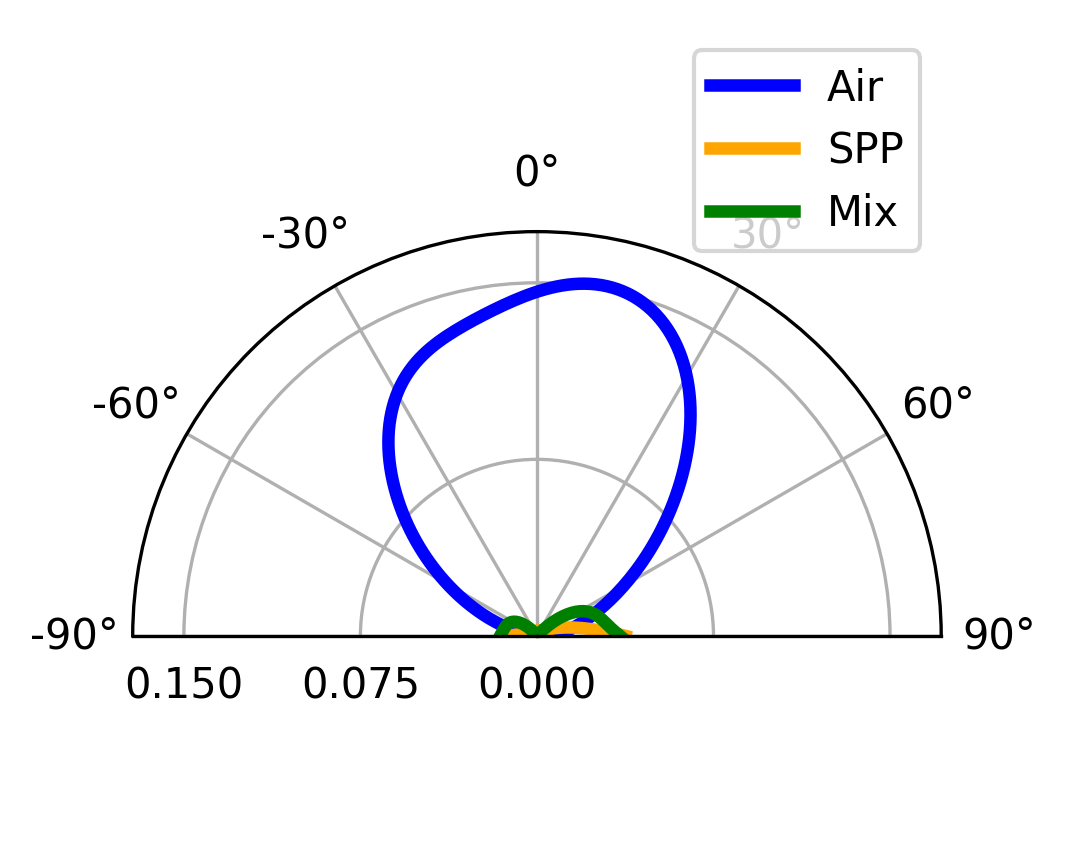

In [150]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(3.5,3.5), dpi=300)
ax = fig.add_subplot(111, projection='polar')

# ax.plot(diagTotYOZ.theta, diagTotYOZ.D/I0, label='Total', color='black', lw=3, ls='--')
ax.plot(diagRegYOZ.theta, diagRegYOZ.D/I0, label='Air',   color='blue',  lw=3)
ax.plot(diagSppYOZ.theta, diagSppYOZ.D/I0, label='SPP',   color='orange',lw=3)
ax.plot(diagMixYOZ.theta, diagMixYOZ.D/I0, label='Mix',   color='green', lw=3)

ax.set_xlim(-np.pi, np.pi)
ax.set_theta_direction(-1)
ax.set_theta_zero_location("N") 
ax.legend()
ax.set_thetamin(-90)
ax.set_thetamax(90)

ax.set_ylim(0, np.max(diagTotXOZ.D/I0)*1.2)
ax.set_yticks([0, 0.075, .15])

#ax.set_ylabel('Diagram D')
plt.show()

In [4]:
diagTotXOZ.D[diagTotXOZ.D<0] = 0 
diagRegXOZ.D[diagRegXOZ.D<0] = 0 
diagSppXOZ.D[diagSppXOZ.D<0] = 0 
diagMixXOZ.D[diagMixXOZ.D<0] = 0


diagTotYOZ.D[diagTotYOZ.D<0] = 0 
diagRegYOZ.D[diagRegYOZ.D<0] = 0 
diagSppYOZ.D[diagSppYOZ.D<0] = 0 
diagMixYOZ.D[diagMixYOZ.D<0] = 0

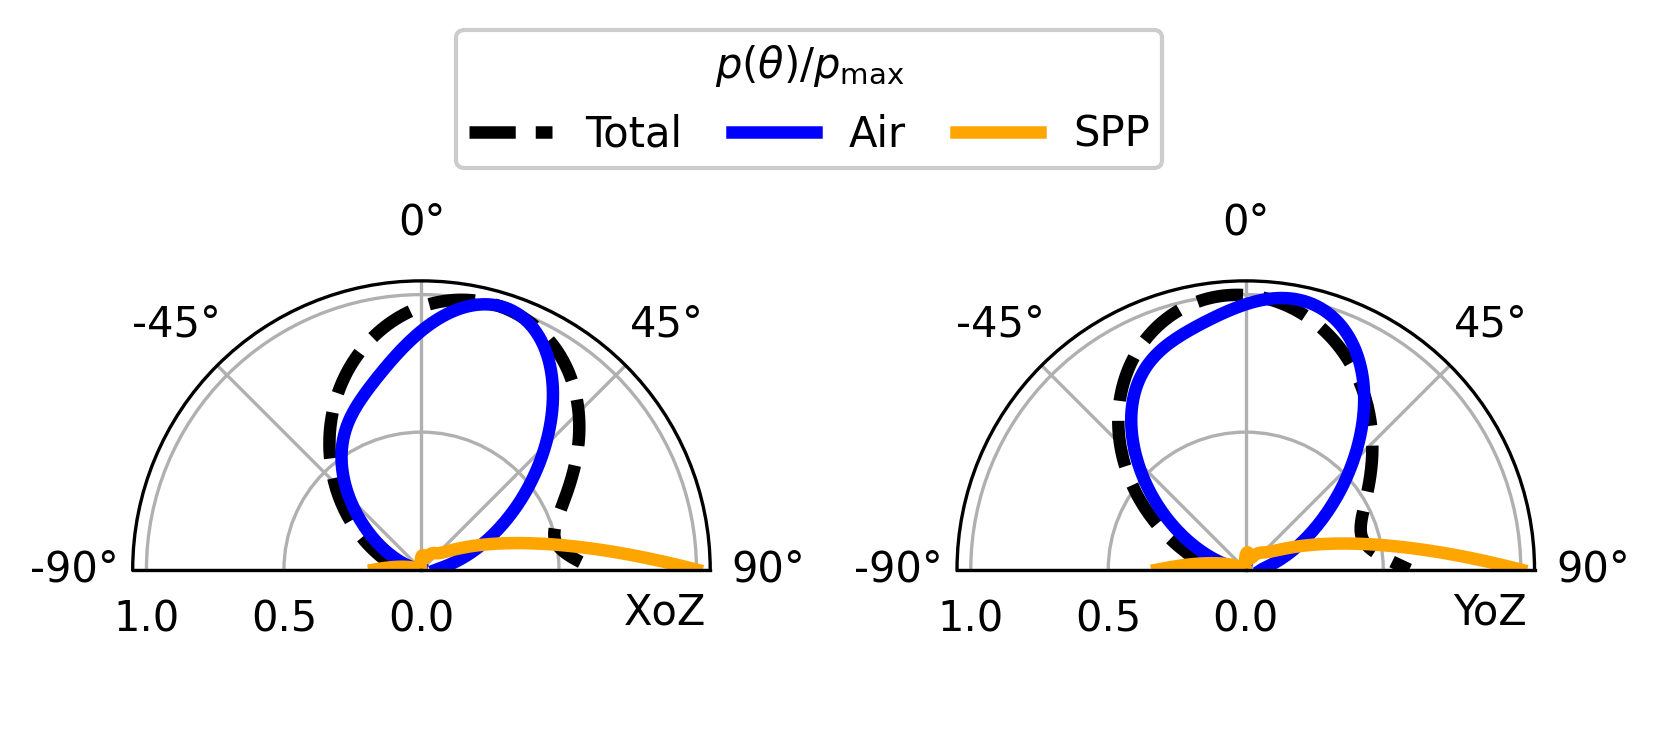

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(6.5, 2.5),
    dpi=300,
    subplot_kw=dict(projection="polar")
)

for ax in axes:
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetamin(-90)
    ax.set_thetamax(90)
    ax.set_xticks([np.deg2rad(-90), np.deg2rad(-45), 0, np.deg2rad(45), np.deg2rad(90)])
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.5, 1])
    ax.grid(True)

# ---------- XOZ ----------
axes[0].plot(
    diagTotXOZ.theta,
    diagTotXOZ.D / np.max(np.abs(diagTotXOZ.D)),
    label="Total", color="black", lw=3, ls="--"
)
axes[0].plot(
    diagRegXOZ.theta,
    diagRegXOZ.D / np.max(np.abs(diagRegXOZ.D)),
    label="Air", color="blue", lw=3
)
axes[0].plot(
    diagSppXOZ.theta,
    diagSppXOZ.D / np.max(np.abs(diagSppXOZ.D)),
    label="SPP", color="orange", lw=3
)

axes[0].text(
    np.deg2rad(100), 0.9,
    s=r"XoZ",
    fontsize=10,
    horizontalalignment='center',
    verticalalignment='center'
)

# ---------- YOZ ----------
axes[1].plot(
    diagTotYOZ.theta,
    diagTotYOZ.D / np.max(np.abs(diagTotYOZ.D)),
    color="black", lw=3, ls="--"
)
axes[1].plot(
    diagRegYOZ.theta,
    diagRegYOZ.D / np.max(np.abs(diagRegYOZ.D)),
    color="blue", lw=3
)
axes[1].plot(
    diagSppYOZ.theta,
    diagSppYOZ.D / np.max(np.abs(diagSppYOZ.D)),
    color="orange", lw=3
)

axes[1].text(
    np.deg2rad(100), 0.9,
    s=r"YoZ",
    fontsize=10,
    horizontalalignment='center',
    verticalalignment='center'
)

# ---------- legend: left, close, with p/pmax label ----------
handles, labels = axes[0].get_legend_handles_labels()


leg = fig.legend(
    handles, labels,
    title=r"$p(\theta)/p_{\max}$",   # label inside legend
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),     # centered above plots
    ncol=4,                         # horizontal layout
    frameon=True,
    fancybox=True,
    framealpha=1.0,
    borderpad=0.3,
    labelspacing=0.6,
    columnspacing=1.2
)

plt.savefig('article_plots/figure 1/diagrams_XOZ_YOZ.png', bbox_inches='tight', dpi=300)
plt.show()

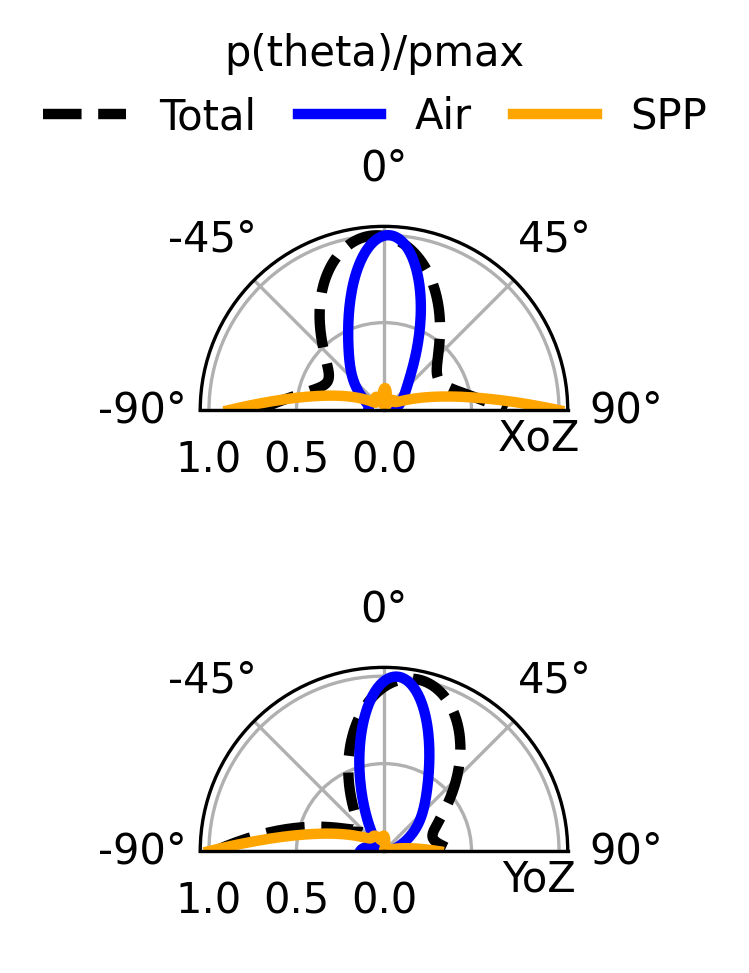

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, 
                         dpi=300, 
                         figsize=(2.5, 3.5),  
                         subplot_kw=dict(projection="polar"))
# plt.subplots_adjust(top=.65, bottom=0, left=0, right=1, hspace=0, wspace=0)

for ax in axes:
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_thetamin(-90)
    ax.set_thetamax(90)
    ax.set_xticks([np.deg2rad(-90), np.deg2rad(-45), 0, np.deg2rad(45), np.deg2rad(90)])
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.5, 1])
    ax.grid(True)

axes[0].plot(diagTotXOZ.theta, diagTotXOZ.D / np.max(np.abs(diagTotXOZ.D)), label="Total", color="black", lw=2.5, ls="--")
axes[0].plot(diagRegXOZ.theta, diagRegXOZ.D / np.max(np.abs(diagRegXOZ.D)), label="Air", color="blue", lw=2.5)
axes[0].plot(diagSppXOZ.theta, diagSppXOZ.D / np.max(np.abs(diagSppXOZ.D)), label="SPP", color="orange", lw=2.5)
axes[0].text(np.deg2rad(100), 0.9, r"XoZ", fontsize=10, ha='center', va='center')

axes[1].plot(diagTotYOZ.theta, diagTotYOZ.D / np.max(np.abs(diagTotYOZ.D)), label="Total", color="black", lw=2.5, ls="--")
axes[1].plot(diagRegYOZ.theta, diagRegYOZ.D / np.max(np.abs(diagRegYOZ.D)), label="Air", color="blue", lw=2.5)
axes[1].plot(diagSppYOZ.theta, diagSppYOZ.D / np.max(np.abs(diagSppYOZ.D)), label="SPP", color="orange", lw=2.5)
axes[1].text(np.deg2rad(100), 0.9, r"YoZ", fontsize=10, ha='center', va='center')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="p(theta)/pmax", loc="upper center", 
        #    bbox_to_anchor=(0.5, 0.97), 
           ncol=3, frameon=False, framealpha=1.0, borderpad=0.3, columnspacing=1.0, handlelength=2.0
           )

# plt.tight_layout()
plt.savefig('article_plots/figure 1/diagrams_XOZ_YOZ_raw.svg')
plt.show()


In [21]:
sweep_spp, diagrams_spp, _ = SweepRunner(base_config, 'R', np.linspace(100, 165, num_points)*ureg.nm, True, False, True, True, False, XOY_SPP, 'spp').run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [01:25<?, ?it/s]


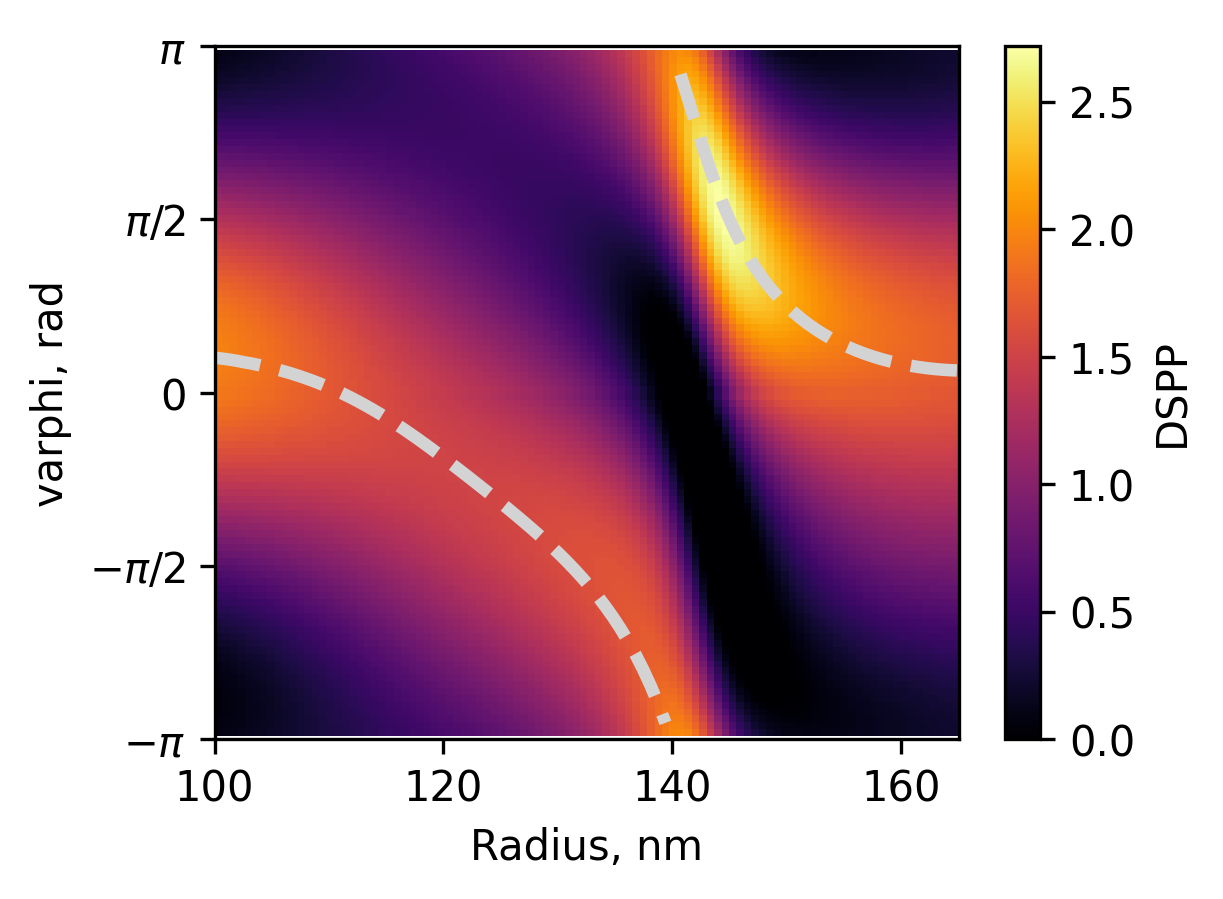

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec

diagrams_spp["phi"] = diagrams_spp["phi"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)
diagrams_spp["R"]  = diagrams_spp["R"].apply(lambda x: x.magnitude if hasattr(x, "magnitude") else x)

pivot_spp = diagrams_spp.pivot(index="phi", columns="R", values="D")



# shift phi from [0, 2π] to [-π, π] and reindex/sort for correct display
phi_vals = pivot_spp.index.values.astype(float)
phi_shift = np.where(phi_vals > np.pi, phi_vals - 2*np.pi, phi_vals)
pivot_spp.index = phi_shift
pivot_spp = pivot_spp.sort_index()

# fig = plt.figure(figsize=(3.5,3), dpi=300)

# gs = GridSpec(1, 2, width_ratios=[20, 1], wspace=0.05)

# ax  = fig.add_subplot(gs[0])
# cax = fig.add_subplot(gs[1])
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)



im =ax.imshow(
    pivot_spp.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot_spp.columns.min()), float(pivot_spp.columns.max()),
        float(pivot_spp.index.min()),   float(pivot_spp.index.max())
    ],
    cmap="inferno",
    vmin=0,
)

phi_values = pivot_spp.index.values.astype(float)
R_values = pivot_spp.columns.values.astype(float)
max_phi_for = []
for r in R_values:
    col = pivot_spp[r].values.astype(float)
    complex_sum = np.sum(col * np.exp(1j * phi_values))
    phi_mean = np.angle(complex_sum)
    if phi_mean > np.pi:
        phi_mean -= 2*np.pi
    if phi_mean <= -np.pi:
        phi_mean += 2*np.pi
    max_phi_for.append(phi_mean)
max_phi_for = np.asarray(max_phi_for, dtype=float)

dphi_raw = np.abs(np.diff(max_phi_for))
breaks = np.where(dphi_raw > np.pi)[0]
phi_plot_spp = max_phi_for.copy()
phi_plot_spp[breaks + 1] = np.nan

dash_style = (0, (7, 3))
ax.plot(R_values, phi_plot_spp,
         color="lightgrey", 
         linewidth=3, 
         label="DSPPmax",
         linestyle='--',
         )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("DSPP")
ax.set_xlabel("Radius, nm")
ax.set_ylabel("varphi, rad")

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]

ax.set_yticks(yticks)
yticklabels = ["$-\\pi$", "$-\\pi/2$", "$0$", "$\\pi/2$", "$\\pi$"]
ax.set_yticklabels(yticklabels)
ax.set_ylim(-np.pi, np.pi)

# plt.tight_layout()
# ax.legend()
plt.savefig('article_plots/figure 1/Dspp_map_raw.svg', dpi=300, bbox_inches="tight")
plt.show()


## Air heatmap

In [8]:
sweep_reg, diagrams_reg, _ = SweepRunner(base_config, 'R', np.linspace(100, 165, num_points)*ureg.nanometer, True, False, True, True, False, XOY_AIR, 'reg', diagram_normalize=None).run(n_jobs=-1)

  0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
import numpy as np
import pandas as pd

def integrate_pattern_over_theta(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    theta_col: str = "theta",
    R_col: str = "R",
    D_col: str = "D",
) -> pd.DataFrame:
    """
    Интегрирует 3D диаграмму D(phi, theta) по theta:
        p(phi, R) = ∫_{theta_min}^{theta_max} D(phi, theta, R) * sin(theta) dtheta

    Возвращает DataFrame с колонками: [R, phi, p]
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[theta_col] = df[theta_col].apply(_to_float)
    df[R_col] = df[R_col].apply(_to_float)
    df[D_col] = df[D_col].apply(_to_float)

    df = df.sort_values([R_col, phi_col, theta_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        th = g[theta_col].to_numpy()
        D = g[D_col].to_numpy()
        y = D * np.sin(th)
        return float(np.trapezoid(y, th))

    out = (
        df.groupby([R_col, phi_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out


def integrate_pattern_over_phi_after_theta(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    R_col: str = "R",
    D_col: str = "D",
) -> pd.DataFrame:
    """
    Интегрирует 2D диаграмму D(phi) по phi:
    p(R) = ∫_{phi_min}^{phi_max} D(phi, theta, R) * sin(theta) dphi

    Возвращает DataFrame с колонками: [R, phi, p]
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[R_col] = df[R_col].apply(_to_float)
    df[D_col] = df[D_col].apply(_to_float)

    df = df.sort_values([R_col, phi_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        ph = g[phi_col].to_numpy()
        D = g[D_col].to_numpy()
        return float(np.trapezoid(D, ph))

    out = (
        df.groupby([R_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out




In [10]:
import numpy as np
import pandas as pd

def normalize_over_phi_per_R(
    df_phiR: pd.DataFrame,
    *,
    R_col: str = "R",
    phi_col: str = "phi",
    I_col: str = "p",          # сюда подайте результат интегрирования по theta
    out_col: str = "D_norm",   # имя нормированной колонки
) -> pd.DataFrame:
    """
    Нормировка для каждого R:
        D_norm(phi, R) = 2π * I(phi, R) / ∫_0^{2π} I(phi, R) dphi
    где I(phi, R) — уже проинтегрированная по theta величина (например, p).
    """

    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = df_phiR.copy()

    df = df.sort_values([R_col, phi_col])

    def _norm_group(g: pd.DataFrame) -> pd.DataFrame:
        phi = g[phi_col].to_numpy(dtype=float)
        I = g[I_col].to_numpy(dtype=float)

        denom = float(np.trapezoid(I, phi))
        if not np.isfinite(denom) or abs(denom) < 1e-30:
            g[out_col] = np.nan
            return g

        g[out_col] = (2.0 * np.pi) * I / denom
        return g

    return df.groupby(R_col, group_keys=False).apply(_norm_group)

# использование:
diagrams_reg_phiR = integrate_pattern_over_theta(diagrams_reg)   # -> колонки [R, phi, p]
diagrams_reg_phiR_norm = normalize_over_phi_per_R(diagrams_reg_phiR, I_col="p", out_col="D")
pivot_air = diagrams_reg_phiR_norm.pivot(index="phi", columns="R", values="D")

  0%|          | 0/100 [03:02<?, ?it/s]
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_90432/622384163.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _integrate_group(g))
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_90432/3991343141.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(R_col, group_keys=False).apply(_norm_group)


In [11]:
def get_max_direction(result: DiagramResult):  
    data = pd.DataFrame({"phi": result.phi, "theta": result.theta, "D": result.D})
    phi_u = np.sort(data["phi"].unique())
    theta_u = np.sort(data["theta"].unique())
    pivot = data.pivot_table(index="theta", columns="phi", values="D", aggfunc='mean')

    pivot = pivot.reindex(index=theta_u, columns=phi_u)
    D_grid = pivot.values

    PHI, THETA = np.meshgrid(phi_u, theta_u, indexing='xy')
    X = D_grid * np.sin(THETA)**2 * np.cos(PHI)
    Y = D_grid * np.sin(THETA)**2 * np.sin(PHI)
    Z = D_grid * np.cos(THETA)*np.sin(THETA)
    
    Px_phi = np.trapezoid(X, phi_u, axis=1)
    Py_phi = np.trapezoid(Y, phi_u, axis=1)
    Pz_phi = np.trapezoid(Z, phi_u, axis=1)

    Px = np.trapezoid(Px_phi, theta_u)
    Py = np.trapezoid(Py_phi, theta_u)
    Pz = np.trapezoid(Pz_phi, theta_u)
    
    phi_eff = np.arctan2(Py, Px)
    theta_eff = np.arctan2(np.sqrt(Px**2 + Py**2), Pz)
    
    return [Px, Py, Pz], [phi_eff, theta_eff]

results_phi_max_air = []
for r_val, group in diagrams_reg.groupby("R"):
    diag = DiagramResult(
        phi=group["phi"].values.astype(float),
        theta=group["theta"].values.astype(float),
        D=group["D"].values.astype(float)
    )
    _, [phi_eff, theta_eff] = get_max_direction(diag)
    results_phi_max_air.append({"R": r_val, "phi_eff": phi_eff, "theta_eff": theta_eff})

phi_air_diag = pd.DataFrame(results_phi_max_air)

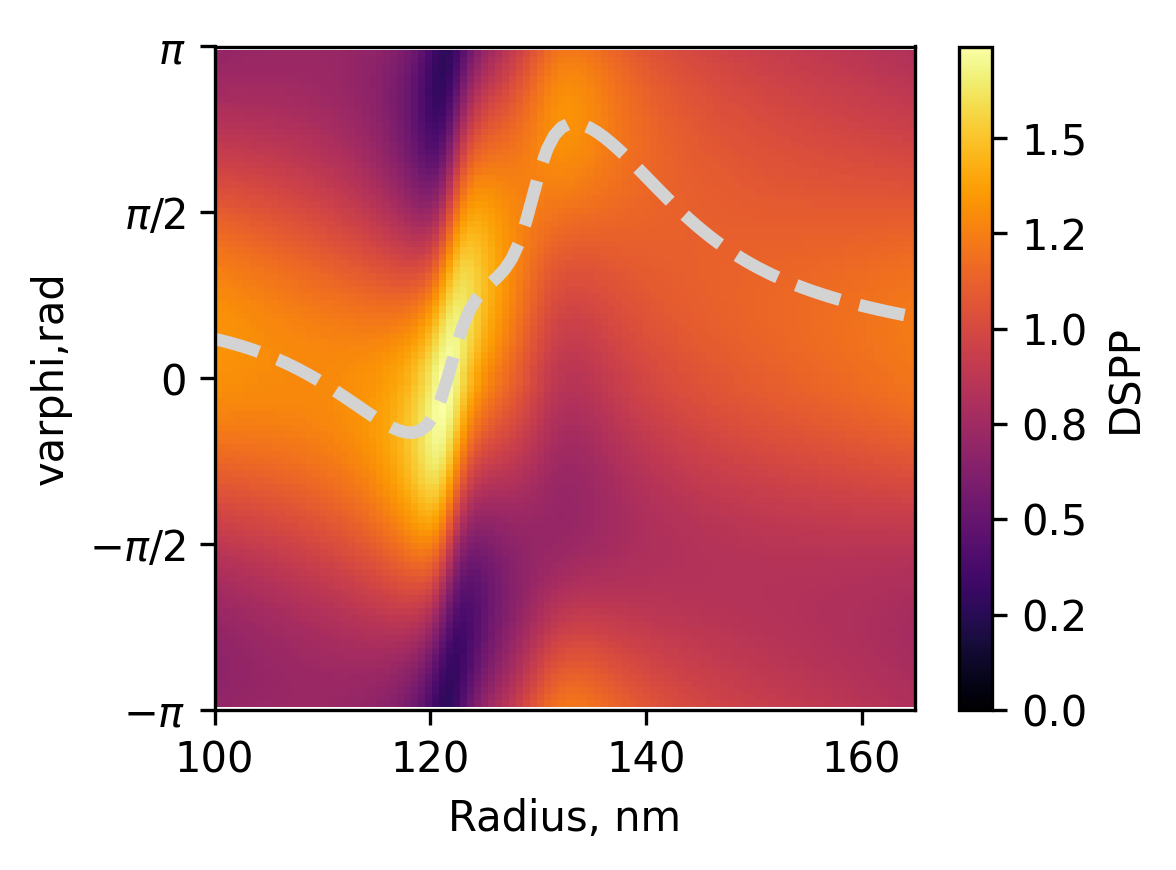

In [15]:
pivot_air = pivot_air.sort_index(axis=1).copy()
phi_vals = pivot_air.index.values.astype(float)
phi_shift = np.where(phi_vals > np.pi, phi_vals - 2*np.pi, phi_vals)
pivot_air.index = phi_shift
pivot_air = pivot_air.sort_index()

R_values = pivot_air.columns.values.astype(float)
phi_values = pivot_air.index.values.astype(float)

# fig = plt.figure(figsize=(3.5,3), dpi=300)

# gs = GridSpec(1, 2, width_ratios=[20, 1], wspace=0.05)

# ax  = fig.add_subplot(gs[0])
# cax = fig.add_subplot(gs[1]) 
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

im = ax.imshow(
    pivot_air.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot_air.columns.min()), float(pivot_air.columns.max()),
        float(pivot_air.index.min()),   float(pivot_air.index.max())
    ],
    cmap="inferno",
    vmin=0,
)

# подготовка линии: привести phi_eff к [-pi, pi], разорвать при больших скачках и добавить обводку
phi_max_air = np.asarray(phi_air_diag.phi_eff, dtype=float)
phi_max_air = (phi_max + np.pi) % (2*np.pi) - np.pi   # нормировка в [-pi, pi]

dphi_raw = np.abs(np.diff(phi_max_air))            # без np.unwrap — сырые скачки
breaks = np.where(dphi_raw > np.pi)[0]
phi_plot_air = phi_max_air.copy()
phi_plot_air[breaks + 1] = np.nan

# dash_style = (0, (7, 3))
ax.plot(R_values, phi_plot_air,
         color="lightgrey", linewidth=3, label="$D_{Air}^{max}$",
         ls='--'
        #  linestyle=dash_style,
        #  path_effects=[pe.Stroke(linewidth=6, foreground='black'), pe.Normal()]
         )


# fig.colorbar(im, cax=cax, label="$D_{Air}$")

cbar = fig.colorbar(im, ax=ax, format='%.1f')
cbar.set_label("DSPP")
ax.set_xlabel("Radius, nm")
ax.set_ylabel("varphi,rad")

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
yticklabels = ["$-\\pi$", "$-\\pi/2$", "$0$", "$\\pi/2$", "$\\pi$"]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_ylim(-np.pi, np.pi)

# ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig('article_plots/figure 1/Dair_map_raw.svg', dpi=300, bbox_inches="tight")
plt.show()

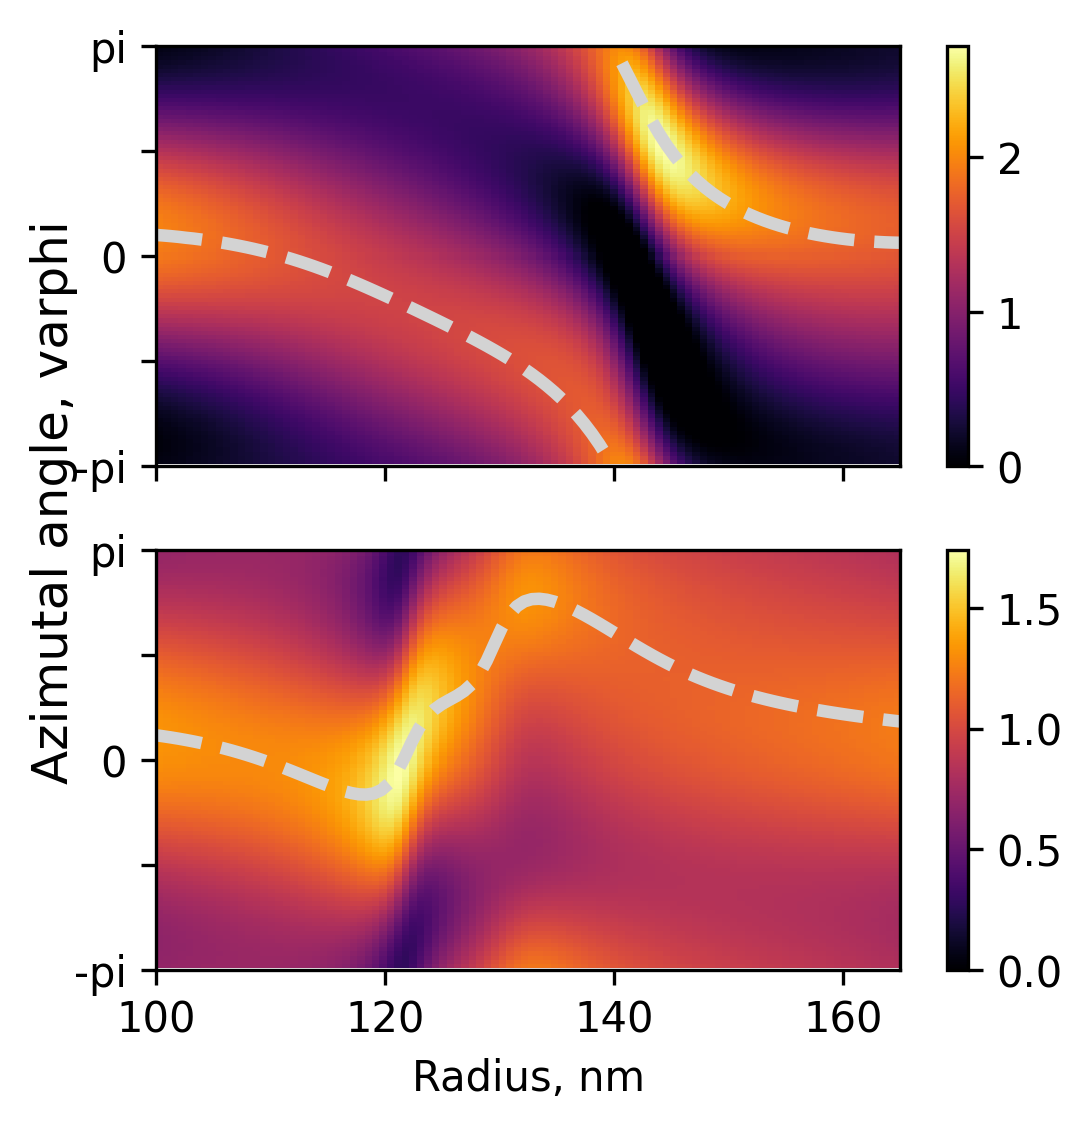

In [24]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4, 4), dpi=300, sharex=True)
ax1, ax2 = axs

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
yticklabels = ["-pi", "", "0", "", "pi"]

map_spp = ax1.imshow(
    pivot_spp.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot_spp.columns.min()), float(pivot_spp.columns.max()),
        float(pivot_spp.index.min()),   float(pivot_spp.index.max())
    ],
    cmap="inferno",
    vmin=0,
)
bar_spp = fig.colorbar(map_spp, ax=ax1, format='%.0f')
ax1.set_yticks(yticks)
ax1.set_yticklabels(yticklabels)
ax1.set_ylim(-np.pi, np.pi)

ax1.plot(R_values, phi_plot_spp, color="lightgrey", linewidth=3, ls='--')


map_air = ax2.imshow(
    pivot_air.values.astype(float),
    aspect="auto",
    origin="lower",
    extent=[
        float(pivot_air.columns.min()), float(pivot_air.columns.max()),
        float(pivot_air.index.min()),   float(pivot_air.index.max())
    ],
    cmap="inferno",
    vmin=0
)

bar_air = fig.colorbar(map_air, ax=ax2, format='%.1f')
ax2.set_xlabel("Radius, nm")
ax2.set_yticks(yticks)
ax2.set_yticklabels(yticklabels)
ax2.set_ylim(-np.pi, np.pi)
ax2.plot(R_values, phi_max_air, color="lightgrey", linewidth=3, ls='--')
fig.supylabel("Azimutal angle, varphi")
plt.savefig('article_plots/figure 1/Dspp_Dair_maps_raw.svg', dpi=300, bbox_inches="tight")

In [57]:
def integrate_pattern_over_theta_one_R(
    diagrams_df: pd.DataFrame,
    *,
    phi_col: str = "phi",
    theta_col: str = "theta",
    D_col: str = "D",
) -> pd.DataFrame:
    
    def _to_float(x):
        if hasattr(x, "magnitude"):
            return float(x.magnitude)
        return float(x)

    df = diagrams_df.copy()
    df[phi_col] = df[phi_col].apply(_to_float)
    df[theta_col] = df[theta_col].apply(_to_float)
    df[D_col] = df[D_col].apply(_to_float)

    df = df.sort_values([ phi_col, theta_col])

    def _integrate_group(g: pd.DataFrame) -> float:
        th = g[theta_col].to_numpy()
        D = g[D_col].to_numpy()
        y = D * np.sin(th)
        return float(np.trapezoid(y, th))

    out = (
        df.groupby([phi_col], as_index=False)
          .apply(lambda g: _integrate_group(g))
          .rename(columns={None: "p"})
          .reset_index(drop=True)
    )
    return out


def normalize_over_phi_one_R(
    df_phiR: pd.DataFrame,
    *,
    phi_col: str = "phi",
    I_col: str = "p",          # сюда подайте результат интегрирования по theta
    out_col: str = "D_norm",   # имя нормированной колонки
) -> pd.DataFrame:

    df = df_phiR.copy()

    df = df.sort_values([phi_col])

    def _norm_group(g: pd.DataFrame) -> pd.DataFrame:
        phi = g[phi_col].to_numpy(dtype=float)
        I = g[I_col].to_numpy(dtype=float)

        denom = float(np.trapezoid(I, phi))
        if not np.isfinite(denom) or abs(denom) < 1e-30:
            g[out_col] = np.nan
            return g

        g[out_col] = (2.0 * np.pi) * I / denom
        return g

    return df.groupby(lambda _: True, group_keys=False).apply(_norm_group)


XOY_SPP = CylindricalGrid(phi=np.linspace(0, 2*np.pi, 100)*ureg.rad, 
                          z=0*ureg.nm, 
                          r=base_config.wl*5)

XOY_AIR = SphericalGrid(
    r= base_config.wl,
    theta = np.linspace(0, np.pi/2, 20) * ureg.rad,
    phi = np.linspace(0, 2*np.pi, 100) * ureg.rad
)

setattr(base_config, 'R', 130*ureg.nm)


diagTotXOY = DiagramCalculator(base_config, XOY_AIR, normalize=None).compute()
diagRegXOY = DiagramCalculator(base_config, XOY_AIR, normalize=None).compute('reg')
diagSppXOY = DiagramCalculator(base_config, XOY_SPP).compute('spp')

diagTotXoY_int = integrate_pattern_over_theta_one_R(diagTotXOY.as_dict())
diagRegXoY_int = integrate_pattern_over_theta_one_R(diagRegXOY.as_dict())

diagTotXoY_norm = normalize_over_phi_one_R(diagTotXoY_int, I_col="p", out_col="D")
diagRegXoY_norm = normalize_over_phi_one_R(diagRegXoY_int, I_col="p", out_col="D")



/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:442: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  re_retval = quad(refunc, a, b, args, full_output, epsabs,
/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:445: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_retval = quad(imfunc, a, b, args, full_output, epsabs,
100%|██████████| 100/100 [00:00<00:00, 185.21it/s]
/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_35956/2276245737.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _integrate_group(g))
/v

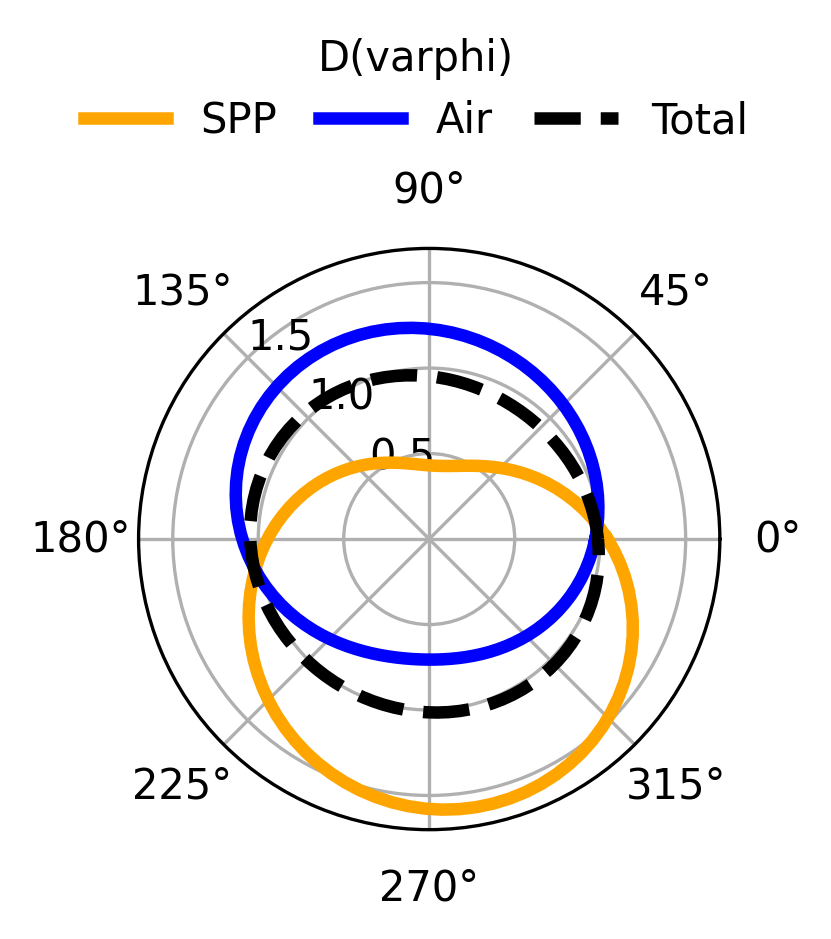

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=1, dpi=300, figsize=(2.5, 3.5),  subplot_kw=dict(projection="polar"))

ax.plot(diagSppXOY.phi, diagSppXOY.D, label='SPP', color='orange', lw=3)
ax.plot(diagRegXoY_norm.phi, diagRegXoY_norm.D, label='Air', color='blue', lw=3)
ax.plot(diagTotXoY_norm.phi, diagTotXoY_norm.D, label='Total', color='black', lw=3, ls='--')


ax.set_theta_zero_location("E")
ax.set_rlabel_position(90+45)
ax.set_ylim(0,1.7)
ax.grid(True)


handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="D(varphi)", loc="upper center", 
        #    bbox_to_anchor=(0.5, 0.97), 
           ncol=3, frameon=False, framealpha=1.0, borderpad=0.4, columnspacing=1.0, handlelength=2.0)

plt.savefig('article_plots/figure 1/diagrams_XOY_raw.svg', bbox_inches='tight', dpi=300)
plt.show()


# Figure 2

## angle D spp vs Fspp

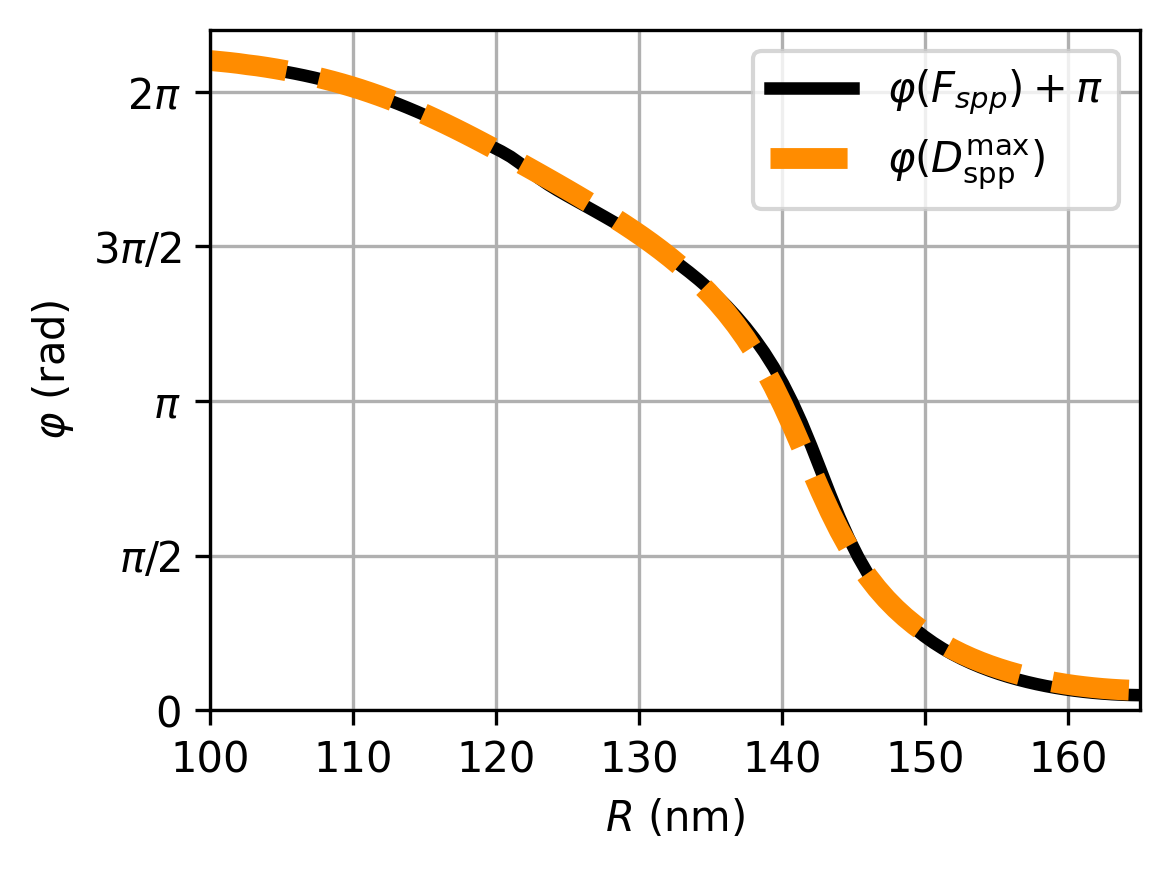

In [59]:
Fx_spp = sweep_reg.Fxspp.magnitude
Fy_spp = sweep_reg.Fyspp.magnitude


phi_F_spp = np.arctan2(Fy_spp, Fx_spp)

plt.figure(figsize=(4,3), dpi=300)

plt.plot(sweep_reg.R, np.unwrap(phi_F_spp)+np.pi+2*np.pi, label="$\\varphi(F_{spp}) + \\pi$", lw=3, c='black')

plt.plot(sweep_reg.R, np.unwrap(max_phi_for)+np.pi*2, label="$\\varphi(D_{\\text{spp}}^{\\text{max}})$", lw=5, ls='--', c='darkorange')


plt.ylim(0,2*np.pi*1.1)

yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$", "$3 \\pi/2$", "$2\\pi$"]
plt.yticks(yticks, yticklabels)

plt.xlim(sweep_reg.R.min().magnitude, sweep_reg.R.max().magnitude)

plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('article_plots/phi_vs_R_spp.svg', dpi=300)
plt.savefig('article_plots/figure 2/phi_vs_R_spp.png', dpi=300)
plt.show()

## angle D air vs F 

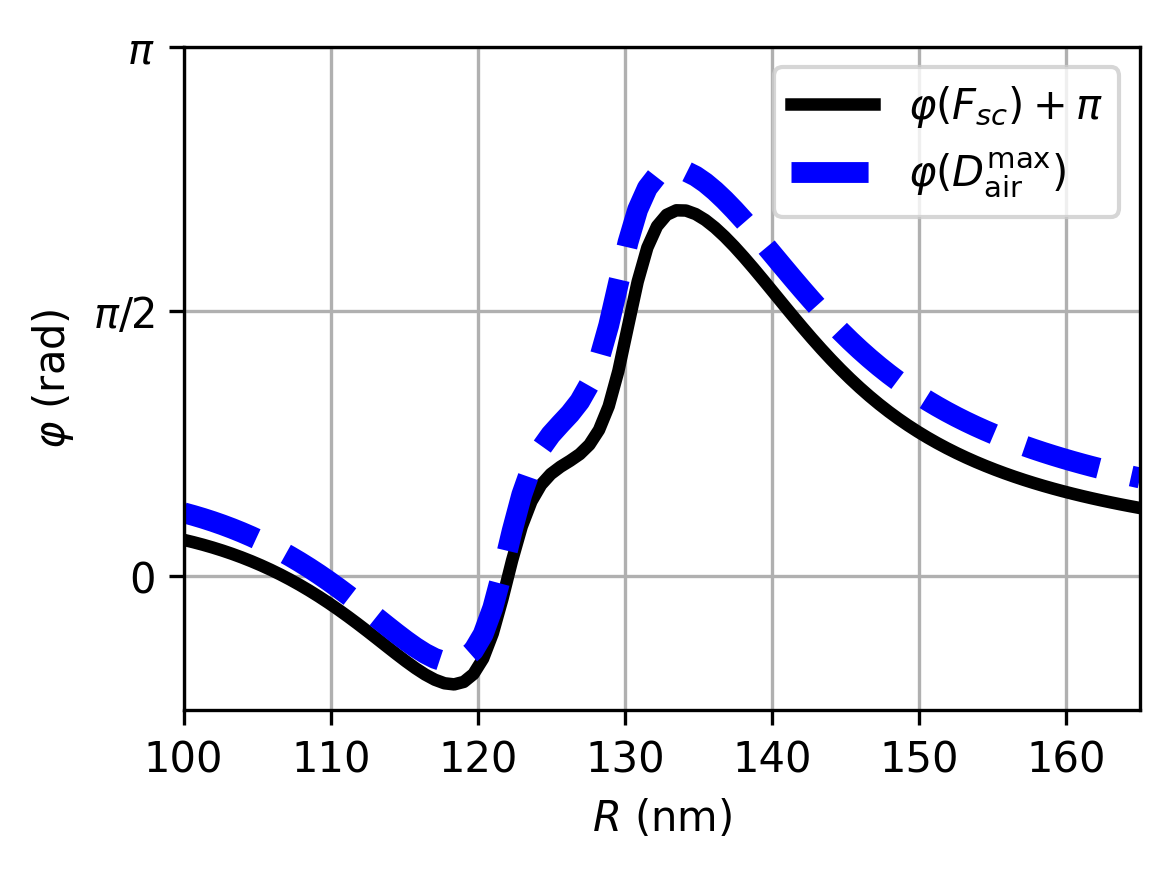

In [60]:
Fx_sc = sweep_reg.Fx - sweep_reg.Fxe0 - sweep_reg.Fxm0 - sweep_reg.Fxspp
Fy_sc = sweep_reg.Fy - sweep_reg.Fyspp

Fx_sc = Fx_sc.magnitude
Fy_sc = Fy_sc.magnitude

phi_F_sc = np.arctan2(Fy_sc, Fx_sc)

plt.figure(figsize=(4,3), dpi=300)

plt.plot(sweep_reg.R, np.unwrap(phi_F_sc)+np.pi, label="$\\varphi(F_{sc}) + \\pi$", lw=3, c='black')

plt.plot(sweep_reg.R, phi_air_diag.phi_eff, label="$\\varphi(D_{\\text{air}}^{\\text{max}})$", lw=5, ls='--', c='blue')


yticks = [0, np.pi/2, np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$"]
plt.yticks(yticks, yticklabels)

plt.xlim(sweep_reg.R.min().magnitude, sweep_reg.R.max().magnitude)

plt.xlabel("$R$ (nm)")
plt.ylabel("$\\varphi$ (rad)")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('article_plots/phi_vs_R_air.svg', dpi=300)
plt.savefig('article_plots/figure 2/phi_vs_R_air.png', dpi=300)
plt.show()

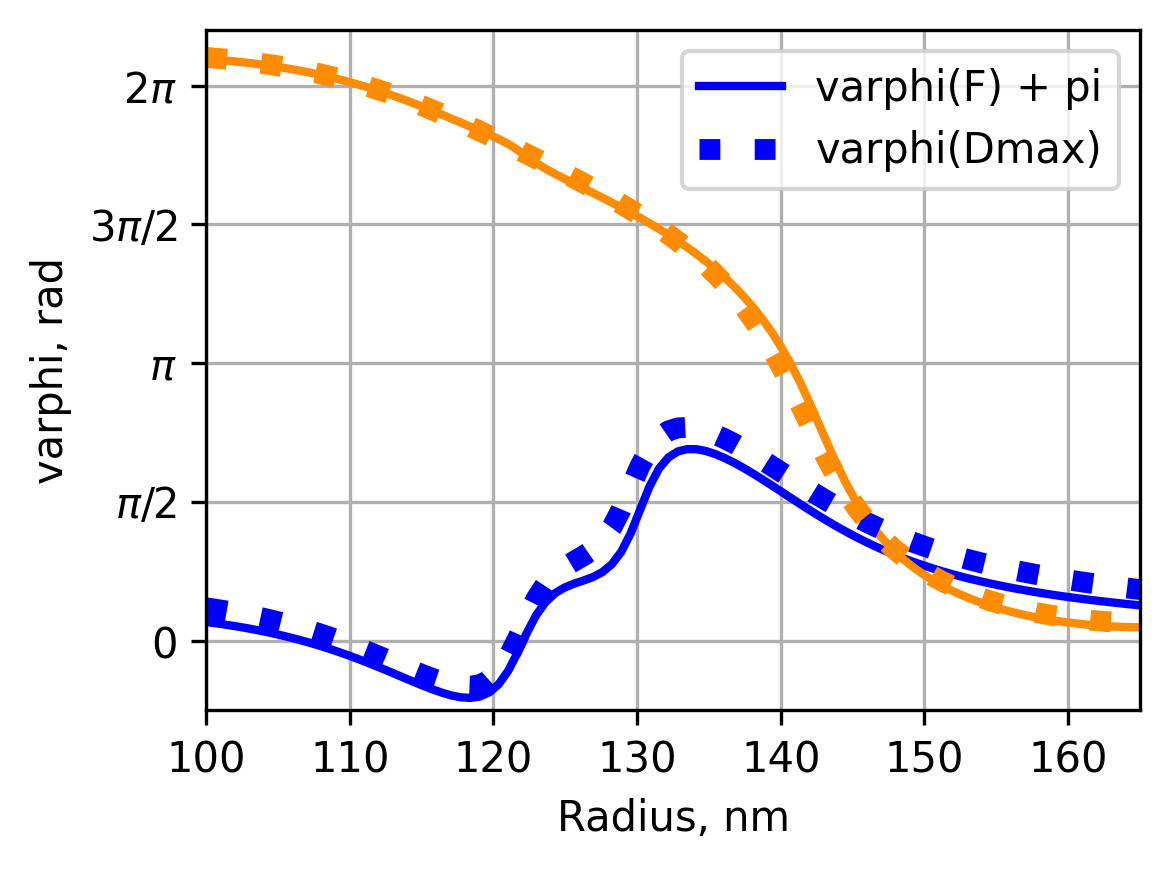

In [61]:
Fx_spp = sweep_reg.Fxspp.magnitude
Fy_spp = sweep_reg.Fyspp.magnitude

Fx_sc = sweep_reg.Fx - sweep_reg.Fxe0 - sweep_reg.Fxm0 - sweep_reg.Fxspp
Fy_sc = sweep_reg.Fy - sweep_reg.Fyspp

Fx_sc = Fx_sc.magnitude
Fy_sc = Fy_sc.magnitude

phi_F_sc = np.arctan2(Fy_sc, Fx_sc)

phi_F_spp = np.arctan2(Fy_spp, Fx_spp)

plt.figure(figsize=(4,3), dpi=300)

plt.plot(sweep_reg.R, np.unwrap(phi_F_sc)+np.pi, label="varphi(F) + pi", lw=2, c='blue')
plt.plot(sweep_reg.R, np.unwrap(phi_F_spp)+np.pi+2*np.pi  ,lw=2, c='darkorange')

plt.plot(sweep_reg.R, phi_air_diag.phi_eff, label="varphi(Dmax)", lw=5, ls=':', c='blue')
plt.plot(sweep_reg.R, np.unwrap(max_phi_for)+np.pi*2, lw=5, ls=':', c='darkorange')


plt.ylim(-0.25*np.pi, 2*np.pi*1.1)

yticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
yticklabels = ["$0$", "$\\pi/2$", "$\\pi$", "$3 \\pi/2$", "$2\\pi$"]
plt.yticks(yticks, yticklabels)

plt.xlim(sweep_reg.R.min().magnitude, sweep_reg.R.max().magnitude)

plt.xlabel("Radius, nm")
plt.ylabel("varphi, rad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('article_plots/figure 2/phi_vs_R_spp_air_raw.svg', dpi=300)
plt.show()

## Fx - Fx spp and Fx sc

In [4]:
Plas = 100 * ureg.milliwatt
S = 10 * ureg.micron**2

E0 = np.sqrt(2 *Plas/(base_config.c_const * base_config.eps0_const * S)).to('V/m')


base_config_free_space = SimulationConfig(
    wl = base_config.wl,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(0),
    psi = 0,
    chi = 0,
    show_warnings=False,
    substrate = 'Air',
    initial_field_type='plane_wave',
    amplitude=E0.magnitude
)

sweep_res_free_space, _, _ = SweepRunner(base_config_free_space, 'R', np.linspace(100, 160, 100)*ureg.nanometer, True, False, False, True, False).run()

F0 = np.max(np.abs(sweep_res_free_space['Fz'].magnitude))

  0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
F0

np.float64(1.3300142841329527e-11)

In [63]:
from MieSppForce.force import field_dx
from MieSppForce.dipoles import initial_field
from MieSppForce import frenel

mu0_const = base_config.mu0_const.magnitude

f_coms_tot = np.loadtxt('fx_fy_circ_900_fromR.txt', delimiter=',', skiprows=8)
p_coms = np.loadtxt('p_circ_900_fromR.txt', delimiter=',', skiprows=8) 
m_coms = np.loadtxt('m_circ_900_fromR.txt', delimiter=',', skiprows=8) 

px = p_coms[:,1] - 1j* p_coms[:,2] 
py = p_coms[:,3] - 1j* p_coms[:,4] 
pz = p_coms[:,5] - 1j* p_coms[:,6] 

mx = m_coms[:,1] - 1j* m_coms[:,2] 
my = m_coms[:,3] - 1j* m_coms[:,4] 
mz = m_coms[:,5] - 1j* m_coms[:,6] 

epsAu = frenel.get_interpolate('Au')
dist = 2

R_coms = p_coms[:,0]

dEdx = np.zeros((len(R_coms), 3), dtype=complex)
dHdx = np.zeros((len(R_coms), 3), dtype=complex)

for i in range(len(R_coms)):
    dEdx[i,:], dHdx[i,:] = field_dx(initial_field, 900, np.deg2rad(25), 1, epsAu, point=[0,0,dist+R_coms[i]], phase=np.pi/2, a_angle=np.pi/4)
    
Fx_press_e = 0.5*np.real( px.conj() * dEdx[:,0] + py.conj() * dEdx[:,1] + pz.conj() * dEdx[:,2] )

Fx_press_m = 0.5*np.real( mx.conj() * dHdx[:,0] + my.conj() * dHdx[:,1] + mz.conj() * dHdx[:,2] )*mu0_const

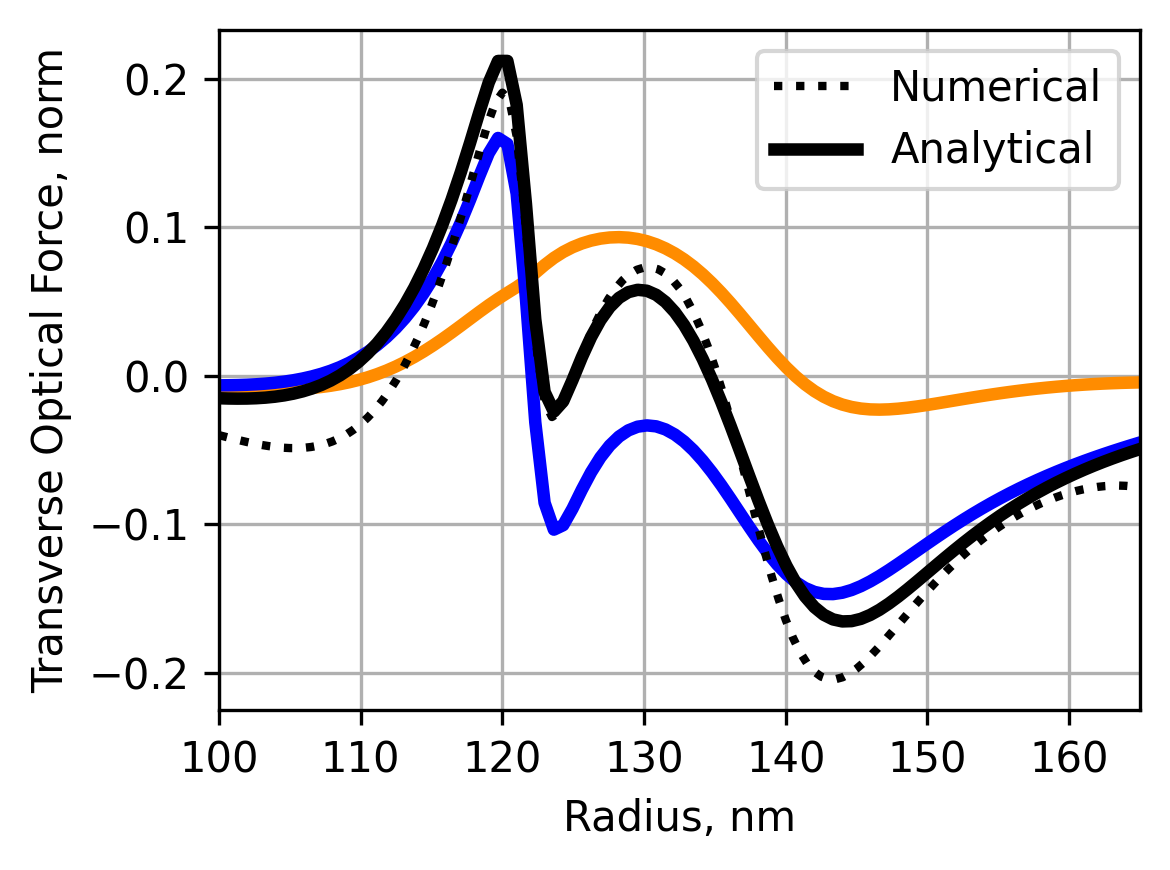

In [64]:
plt.figure(figsize=(4,3), dpi=300)

Fyspp = sweep_spp.Fyspp.magnitude
Fy = sweep_spp.Fy.magnitude
Fy_sc = sweep_reg.Fy.magnitude - sweep_reg.Fyspp.magnitude

plt.plot(sweep_spp.R, Fyspp/F0, c='darkorange', lw=3)
plt.plot(sweep_spp.R, Fy_sc/F0, c='blue', lw=3)
plt.plot(f_coms_tot[:,0], f_coms_tot[:,2]/F0, label="Numerical", c='black', lw=2, ls=':')
plt.plot(sweep_spp.R, Fy/F0, label="Analytical", c='black', lw=3)

plt.xlim(sweep_spp.R.magnitude[0], sweep_spp.R.magnitude[-1])
plt.xlabel("Radius, nm")
plt.ylabel("Transverse Optical Force, norm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('article_plots/figure 2/Fy_vs_R_air_raw.svg', dpi=300)

plt.show()

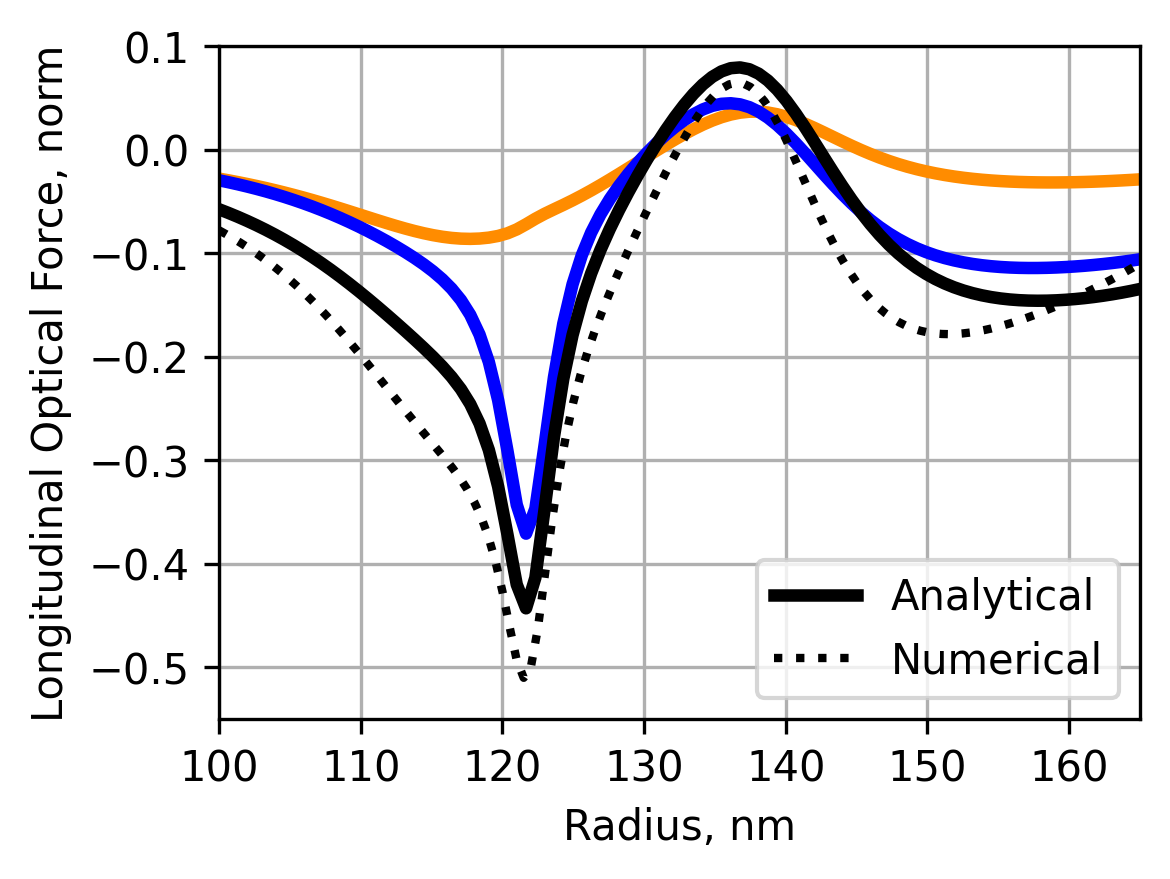

In [65]:
plt.figure(figsize=(4,3), dpi=300)

Fxspp = sweep_spp.Fxspp.magnitude
Fx = sweep_spp.Fx.magnitude - sweep_reg.Fxe0.magnitude - sweep_reg.Fxm0.magnitude
Fx_sc = Fx - Fxspp


plt.plot(sweep_spp.R, Fxspp/F0, c='darkorange', lw=3)
plt.plot(sweep_spp.R, Fx_sc/F0, c='blue', lw=3)
plt.plot(sweep_spp.R, Fx/F0, label="Analytical", c='black', lw=3)


plt.plot(f_coms_tot[:,0], (f_coms_tot[:,1]-Fx_press_e-Fx_press_m)/F0, label="Numerical", c='black', lw=2, ls=':')


plt.xlim(sweep_spp.R.magnitude[0], sweep_spp.R.magnitude[-1])
plt.xlabel("Radius, nm")
plt.ylabel("Longitudinal Optical Force, norm")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.ylim(-0.55, 0.1)
plt.savefig('article_plots/figure 2/Fx_vs_R_air_raw.svg', dpi=300)

plt.show()

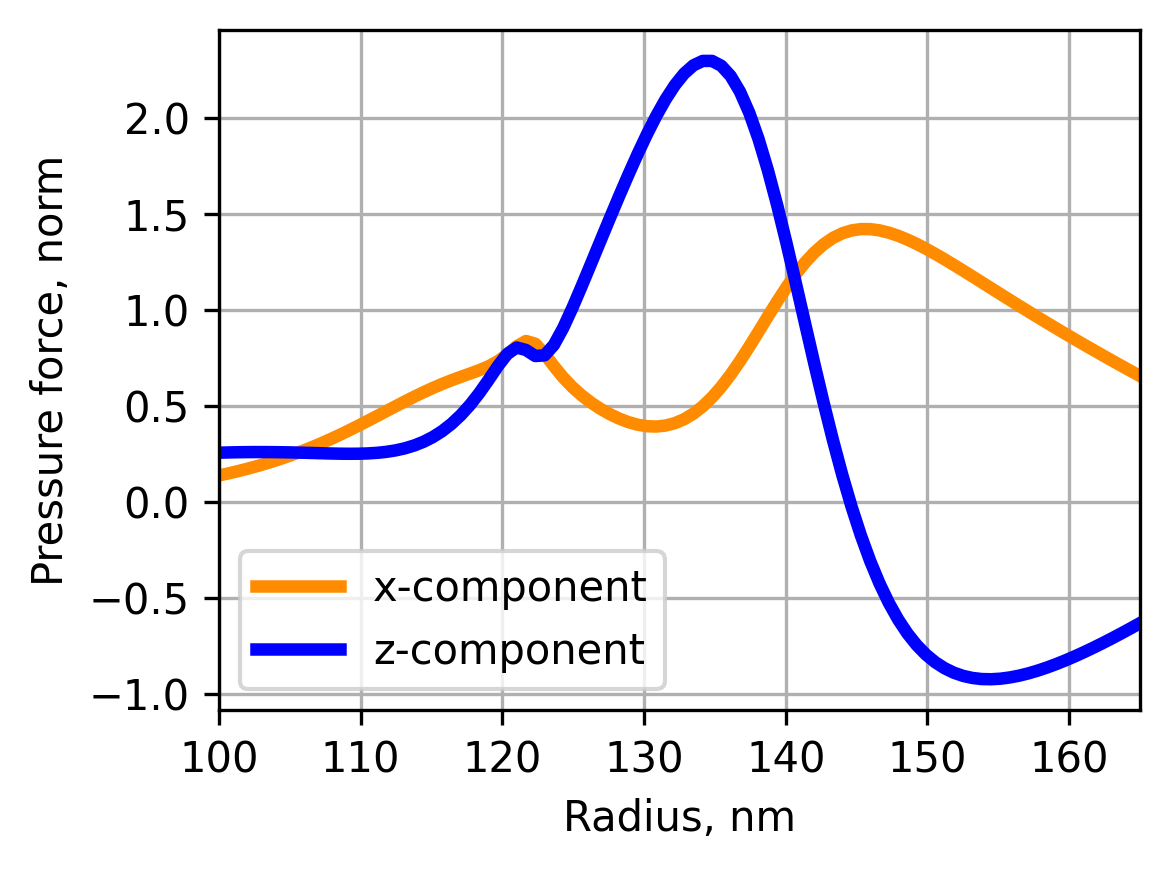

In [11]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False

plt.figure(figsize=(4,3), dpi=300)

Fx_press = sweep_spp.Fxe0.magnitude + sweep_spp.Fxm0.magnitude
Fz_press = sweep_spp.Fze0.magnitude + sweep_spp.Fzm0.magnitude


plt.plot(sweep_spp.R, Fx_press/F0, c='darkorange', lw=3, label="x-component")
plt.plot(sweep_spp.R, Fz_press/F0, c='blue', lw=3, label="z-component")
# plt.plot(sweep_spp.R, Fz_spp/F0, label="SPP", c='green', lw=3)
# plt.plot(sweep_spp.R, Fz_sc/F0, label="SC", c='red', lw=3)

# plt.plot(f_coms_tot[:,0], (f_coms_tot[:,1]-Fx_press_e-Fx_press_m)/F0, label="Numerical", c='black', lw=2, ls=':')


plt.xlim(sweep_spp.R.magnitude[0], sweep_spp.R.magnitude[-1])
plt.xlabel("Radius, nm")
plt.ylabel("Pressure force, norm")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.ylim(-0.55, 0.1)
plt.savefig('article_plots/figure 2/Fpress_vs_R_raw.svg', dpi=300)

plt.show()

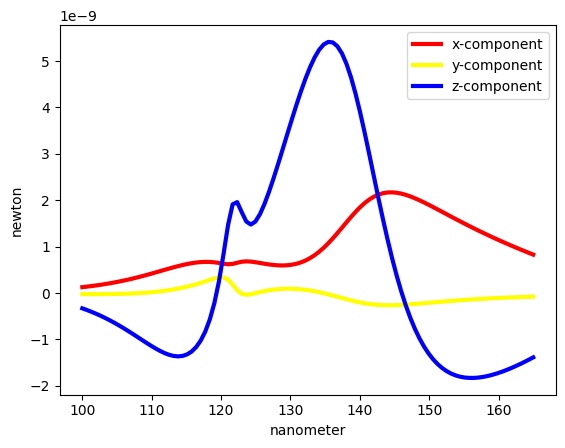

In [23]:
plt.plot(sweep_spp.R, sweep_spp.Fx, c='red', lw=3, label="x-component")
plt.plot(sweep_spp.R, sweep_spp.Fy, c='yellow', lw=3, label="y-component")
plt.plot(sweep_spp.R, sweep_spp.Fz, c='blue', lw=3, label="z-component")
plt.legend()

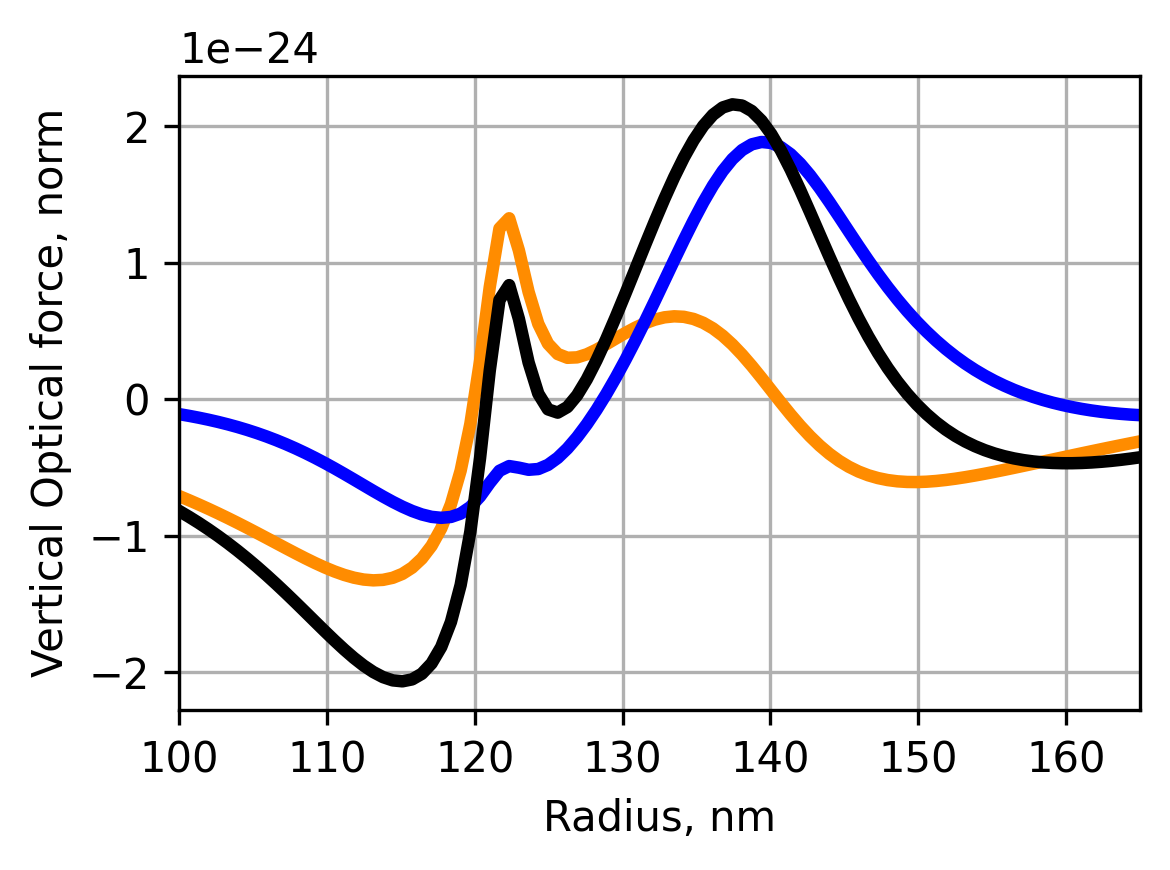

In [15]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False

plt.figure(figsize=(4,3), dpi=300)

Fz_spp = sweep_spp.Fzspp.magnitude
Fz_sc = sweep_spp.Fz.magnitude - Fz_press - Fz_spp


plt.plot(sweep_spp.R, Fz_spp, c='darkorange', lw=3)
plt.plot(sweep_spp.R, Fz_sc, c='blue', lw=3)
plt.plot(sweep_spp.R, (Fz_spp+Fz_sc), c='black', lw=3)

plt.xlim(sweep_spp.R.magnitude[0], sweep_spp.R.magnitude[-1])
plt.xlabel("Radius, nm")
plt.ylabel("Vertical Optical force, norm")
# plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.ylim(-0.55, 0.1)
plt.savefig('article_plots/figure 2/Fz_sc_vs_R_raw.svg', dpi=300)

plt.show()

# Figure 3

## Fy from psi and chi

In [1]:
from MieSppForce.simulation import SimulationConfig, SweepRunner2D
import numpy as np
from pint import UnitRegistry
ureg = UnitRegistry()


chi_values = np.linspace(-np.pi/4,  np.pi/4, 200)
psi_values = np.linspace(0, np.pi, 200)

base_config_R_psi = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=122*ureg.nm,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(25),
    chi = chi_values[0],
    psi = psi_values[0],
    show_warnings=False,
    initial_field_type='plane_wave',
)



runner_chi_psi = SweepRunner2D(
    base_config_R_psi,
    primary_param="chi",
    primary_values=chi_values,
    secondary_param="psi",
    secondary_values=psi_values,
    compute_dipoles=True,
    compute_diagram=False,
    compute_force=True,
    compute_fields=False,
    parallel_param="primary",
    enable_parallel=False
)

df_sweep_chi_psi, _, _ = runner_chi_psi.run(n_jobs=1)

/Users/semyon_b/git/SPP_ANALYTICAL/.venv/lib/python3.13/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
chi sweep: 100%|██████████| 200/200 [01:40<00:00,  1.99it/s]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def _to_numeric(value, unit=None):
    if hasattr(value, "to"):
        return value.to(unit).magnitude if unit else value.magnitude
    if hasattr(value, "magnitude"):
        return value.magnitude
    return float(value)

sweep_par_x = 'chi'
sweep_par_y = 'psi'

heatmap_r_psi = df_sweep_chi_psi.to_dataframe().copy()
heatmap_r_psi[sweep_par_x+"_rad"] = heatmap_r_psi[sweep_par_x].apply(_to_numeric)
heatmap_r_psi[sweep_par_y+"_rad"] = heatmap_r_psi[sweep_par_y].apply(_to_numeric)
heatmap_r_psi["Fy_N_full"] = heatmap_r_psi["Fy"].apply(lambda v: _to_numeric(v, "newton"))
heatmap_r_psi["Fy_N_spp"] = heatmap_r_psi["Fyspp"].apply(lambda v: _to_numeric(v, "newton"))
heatmap_r_psi["Fy_N_air"] = heatmap_r_psi["Fy_N_full"] - heatmap_r_psi["Fy_N_spp"]

plt_comp = 'tot'

if plt_comp == 'air':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_air")
elif plt_comp == 'spp':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_spp")
elif plt_comp == 'tot':
    pivot_r_psi = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_full")

pivot_r_psi_full = heatmap_r_psi.pivot(index=sweep_par_y+"_rad", columns=sweep_par_x+"_rad", values="Fy_N_full")
pivot_r_psi_full = pivot_r_psi_full.sort_index().sort_index(axis=1)

pivot_r_psi = pivot_r_psi.sort_index().sort_index(axis=1)

vmax = np.nanmax(np.abs(pivot_r_psi_full.values)) or 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

x_vals = pivot_r_psi.columns.to_numpy(dtype=float)
y_vals = pivot_r_psi.index.to_numpy(dtype=float)

dx = np.min(np.diff(x_vals)) if len(x_vals) > 1 else 1.0
dy = np.min(np.diff(y_vals)) if len(y_vals) > 1 else 1.0
x_pad = 0.5 * dx
y_pad = 0.5 * dy

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
im = ax.imshow(
    pivot_r_psi.values,
    origin="lower",
    aspect="auto",
    extent=[
        x_vals.min() - x_pad, x_vals.max() + x_pad,
        y_vals.min() - y_pad, y_vals.max() + y_pad,
    ],
    cmap="bwr",
    norm=norm,
)

# Keep axis limits exactly on heatmap borders.
ax.set_xlim(x_vals.min() - x_pad, x_vals.max() + x_pad)
ax.set_ylim(y_vals.min() - y_pad, y_vals.max() + y_pad)


cbar = plt.colorbar(im, ax=ax, label="$F_y$ (N)")
ax.set_xlabel(f"$\\{sweep_par_x}$ (rad)")
ax.set_ylabel(f"$\\{sweep_par_y}$ (rad)")
# ax.set_title(f"$F_y^{{{plt_comp}}}$ vs $\\{sweep_par_x}$ and $\\{sweep_par_y}$ at $R$={base_config_R_psi.R.magnitude} nm")
ax.set_xticks([-np.pi/4,-np.pi/8, 0,np.pi/8, np.pi/4])
ax.set_xticklabels(["$-\\pi/4$", "$-\\pi/8$", "0", "$\\pi/8$", "$\\pi/4$"])

yticks = [0, np.pi/4, np.pi/2, np.pi*3/4, np.pi]
yticklabels = ["$0$", "$\\pi/4$", "$\\pi/2$", "$3 \\pi/4$", "$\\pi$"]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

plt.tight_layout()
plt.show()

NameError: name 'df_sweep_chi_psi' is not defined

MIN: chi = -0.201282946398341 psi = 2.3522477657531615 Fy = -3.3547268127652466e-25
MAX: chi = 0.201282946398341 psi = 0.7893448878366315 Fy = 3.3547268127652493e-25


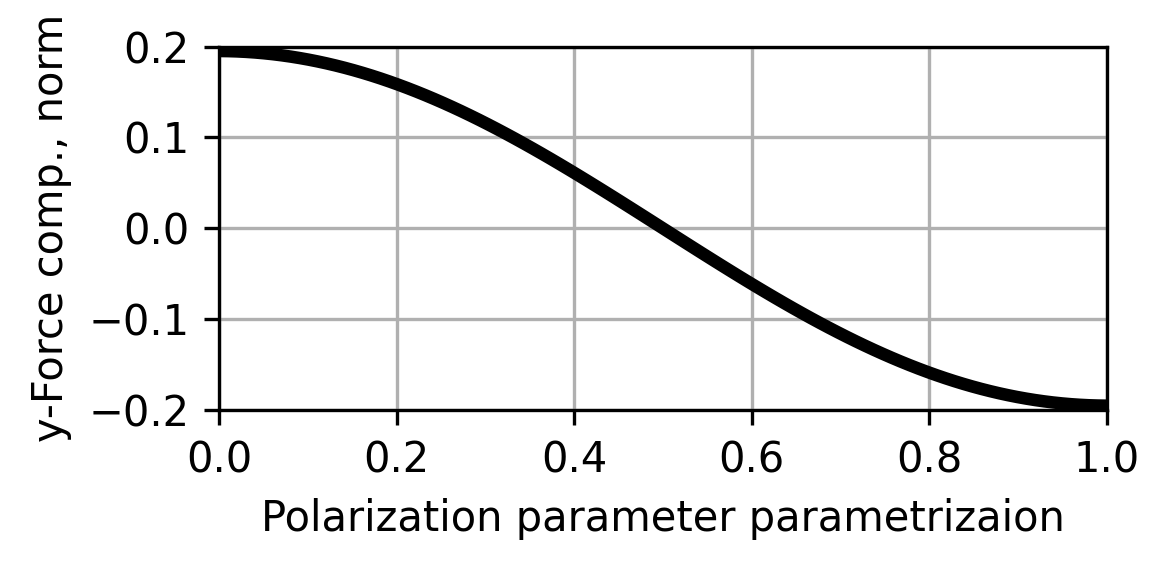

In [112]:
from matplotlib.colors import TwoSlopeNorm
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False

pivot = pivot_r_psi.sort_index().sort_index(axis=1)

x_vals = pivot.columns.to_numpy(dtype=float)  # chi
y_vals = pivot.index.to_numpy(dtype=float)    # psi
Z = pivot.to_numpy(dtype=float)               # Fy[y_i, x_j]

flat = Z.ravel()
mask = np.isfinite(flat)

flat_masked = flat.copy()
flat_masked[~mask] = np.nan

idx_min = int(np.nanargmin(flat_masked))
idx_max = int(np.nanargmax(flat_masked))

H, W = Z.shape
iy_min, ix_min = idx_min // W, idx_min % W
iy_max, ix_max = idx_max // W, idx_max % W

chi_min, psi_min, Fy_min = x_vals[ix_min], y_vals[iy_min], Z[iy_min, ix_min]
chi_max, psi_max, Fy_max = x_vals[ix_max], y_vals[iy_max], Z[iy_max, ix_max]

print("MIN: chi =", chi_min, "psi =", psi_min, "Fy =", Fy_min)
print("MAX: chi =", chi_max, "psi =", psi_max, "Fy =", Fy_max)

N = 100
t = np.linspace(0.0, 1.0, N)
chi_line = chi_min + t * (chi_max - chi_min)
psi_line = psi_min + t * (psi_max - psi_min)

def bilinear_interp_regular_grid(x_vals, y_vals, Z, xq, yq):
    xq = np.asarray(xq, dtype=float)
    yq = np.asarray(yq, dtype=float)

    ix = np.searchsorted(x_vals, xq, side="right") - 1
    iy = np.searchsorted(y_vals, yq, side="right") - 1
    ix = np.clip(ix, 0, len(x_vals) - 2)
    iy = np.clip(iy, 0, len(y_vals) - 2)

    x0 = x_vals[ix]
    x1 = x_vals[ix + 1]
    y0 = y_vals[iy]
    y1 = y_vals[iy + 1]

    tx = (xq - x0) / (x1 - x0 + 1e-300)
    ty = (yq - y0) / (y1 - y0 + 1e-300)

    z00 = Z[iy, ix]
    z10 = Z[iy, ix + 1]
    z01 = Z[iy + 1, ix]
    z11 = Z[iy + 1, ix + 1]

    z0 = z00 * (1 - tx) + z10 * tx
    z1 = z01 * (1 - tx) + z11 * tx
    z = z0 * (1 - ty) + z1 * ty
    return z

Fy_line = bilinear_interp_regular_grid(x_vals, y_vals, Z, chi_line, psi_line)


plt.figure(figsize=(4, 2.0), dpi=300)
plt.plot(t, Fy_line/F0, lw=3, c="black", label=r"$F_y(\chi,\psi)$")
plt.xlim(0, 1)
plt.ylim(-0.2,0.2)
plt.xlabel("Polarization parameter parametrizaion")
plt.ylabel("y-Force comp., norm")
plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.savefig('article_plots/figure 3/Fy_chi_psi_line_raw.svg', dpi=300)
plt.show()


In [4]:
from MieSppForce.simulation import SimulationConfig, OpticalForceCalculator

base_config_single_free_space= SimulationConfig(
    wl=900 * ureg.nanometer,
    R=122*ureg.nm,
    dist=2 * ureg.nanometer,
    angle=np.deg2rad(0),
    chi = 0,
    psi = 0,
    show_warnings=False,
    initial_field_type='plane_wave',
    substrate='Air'
)

    
    
F0 = OpticalForceCalculator(base_config_single_free_space).compute()
F0=F0.as_dict()['Fz'].magnitude

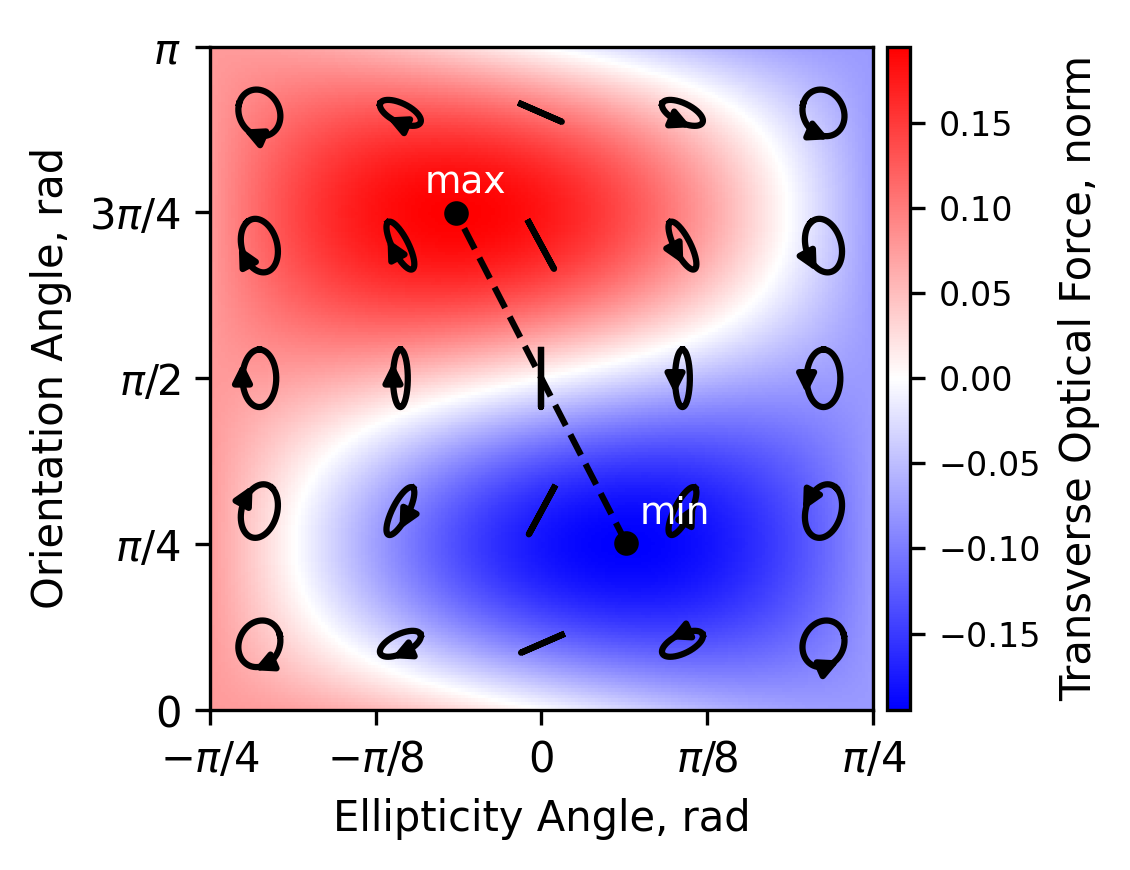

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False


def _centers_to_edges(v):
    v = np.asarray(v, dtype=float)
    e = np.empty(v.size + 1, dtype=float)
    e[1:-1] = 0.5 * (v[:-1] + v[1:])
    e[0] = v[0] - 0.5 * (v[1] - v[0])
    e[-1] = v[-1] + 0.5 * (v[-1] - v[-2])
    return e


def draw_polarization_ellipse(
    ax, center_chi, center_psi, psi, chi, semi_major_px=26, color="black", show_arrow=False
):
    ratio = np.abs(np.tan(chi))
    t = np.linspace(0.0, 2.0 * np.pi, 360, endpoint=False)

    x0 = np.cos(t)
    y0 = ratio * np.sin(t)

    c, s = np.cos(psi), np.sin(psi)
    xr = x0 * c - y0 * s
    yr = x0 * s + y0 * c

    center_disp = ax.transData.transform((center_chi, center_psi))
    pts_disp = np.column_stack([
        center_disp[0] + semi_major_px * xr,
        center_disp[1] + semi_major_px * yr,
    ])
    pts_data = ax.transData.inverted().transform(pts_disp)

    ax.plot(pts_data[:, 0], pts_data[:, 1], color=color, lw=1.5, zorder=6)

    if show_arrow and chi != 0:
        p_prev = np.roll(pts_disp, 1, axis=0)
        p_next = np.roll(pts_disp, -1, axis=0)
        v_prev = pts_disp - p_prev
        v_next = p_next - pts_disp

        n_prev = np.hypot(v_prev[:, 0], v_prev[:, 1])
        n_next = np.hypot(v_next[:, 0], v_next[:, 1])
        cross = np.abs(v_prev[:, 0] * v_next[:, 1] - v_prev[:, 1] * v_next[:, 0])
        denom = n_prev * n_next + 1e-12
        sin_theta = cross / denom
        local_scale = 0.5 * (n_prev + n_next)
        curvature = sin_theta / (local_scale + 1e-12)

        i0 = int(np.argmin(curvature))

        i_prev = (i0 - 2) % len(pts_disp)
        i_next = (i0 + 2) % len(pts_disp)
        tangent = pts_disp[i_next] - pts_disp[i_prev]
        norm_t = np.hypot(tangent[0], tangent[1])
        if norm_t > 0:
            tangent = tangent / norm_t
            direction = 1.0 if chi > 0 else -1.0
            tail_disp = pts_disp[i0]
            head_disp = tail_disp + direction * (0.55 * semi_major_px) * tangent
            arrow_data = ax.transData.inverted().transform(np.vstack([tail_disp, head_disp]))

            ax.annotate(
                "",
                xy=(arrow_data[1, 0], arrow_data[1, 1]),
                xytext=(arrow_data[0, 0], arrow_data[0, 1]),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=color,
                    lw=1.5,
                    mutation_scale=9,
                    shrinkA=0,
                    shrinkB=0,
                ),
                zorder=8,
                annotation_clip=False,
            )


Zmap = pivot_r_psi.values / F0
vmax = np.nanmax(np.abs(pivot_r_psi_full.values / F0))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

x_vals = pivot_r_psi.columns.to_numpy(dtype=float)
y_vals = pivot_r_psi.index.to_numpy(dtype=float)
x_edges = _centers_to_edges(x_vals)
y_edges = _centers_to_edges(y_vals)

# min/max points and connecting line
Z = Zmap
h, w = Z.shape
idx_min = int(np.nanargmin(Z))
idx_max = int(np.nanargmax(Z))
iy_min, ix_min = divmod(idx_min, w)
iy_max, ix_max = divmod(idx_max, w)

chi_min, psi_min = x_vals[ix_min], y_vals[iy_min]
chi_max, psi_max = x_vals[ix_max], y_vals[iy_max]

fig, ax = plt.subplots(figsize=(4, 3.), dpi=300)
im = ax.pcolormesh(
    x_edges,
    y_edges,
    Zmap,
    cmap="bwr",
    norm=norm,
    shading="flat",
    rasterized=True,
    zorder=1,
 )

ax.set_xlim(x_vals[0], x_vals[-1])
ax.set_ylim(y_vals[0], y_vals[-1])
ax.set_box_aspect(1)

ax.plot([chi_min, chi_max], [psi_min, psi_max], ls="--", lw=1.5, c="black", zorder=4)
ax.scatter([chi_min], [psi_min], c="black", s=24, zorder=8)
ax.scatter([chi_max], [psi_max], c="black", s=24, zorder=8)
dx_label = 0.02 * (x_vals[-1] - x_vals[0])
dy_label = 0.03 * (y_vals[-1] - y_vals[0])
ax.text(chi_min + dx_label, psi_min + dy_label, "min", color="white", fontsize=9, zorder=9)
ax.text(chi_max - 2.4 * dx_label, psi_max + dy_label, "max", color="white", fontsize=9, zorder=9)

# -------- Polarization ellipse grid --------
# range in chi / psi
chi_grid_min = -np.pi / 4 * 0.85
chi_grid_max = np.pi / 4 * 0.85
psi_grid_min = 0.0 + 0.1 * np.pi
psi_grid_max = np.pi * 0.9

# number of ellipses along each axis
n_chi = 5
n_psi = 5

# ellipse style
ellipse_size_px = 30
ellipse_color = "black"
show_handedness = True
show_grid_centers = False

chi_grid = np.linspace(chi_grid_min, chi_grid_max, n_chi)
psi_grid = np.linspace(psi_grid_min, psi_grid_max, n_psi)

for psi0 in psi_grid:
    for chi0 in chi_grid:
        draw_polarization_ellipse(
            ax,
            center_chi=chi0,
            center_psi=psi0,
            psi=psi0,
            chi=chi0,
            semi_major_px=ellipse_size_px,
            color=ellipse_color,
            show_arrow=show_handedness,
        )

if show_grid_centers:
    CHI, PSI = np.meshgrid(chi_grid, psi_grid)
    ax.scatter(CHI.ravel(), PSI.ravel(), c="black", s=6, zorder=7)

cax = ax.inset_axes([1.02, 0.0, 0.035, 1.0], transform=ax.transAxes)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Transverse Optical Force, norm")
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel("Ellipticity Angle, rad")
ax.set_ylabel("Orientation Angle, rad")

ax.set_xticks([-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4])
ax.set_xticklabels([r"$-\pi/4$", r"$-\pi/8$", "0", r"$\pi/8$", r"$\pi/4$"])
yticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
yticklabels = [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

plt.tight_layout()
plt.savefig('article_plots/figure 3/Fy_chi_psi_pat_raw.svg', dpi=300)
plt.show()

## Polarization ellipse sanity check

Interactive check for ellipse geometry from $\psi$ (orientation) and $\chi$ (ellipticity).

Expected behavior:
- linear polarization at $\chi=0$
- circular polarization only at $|\chi|=\pi/4$
- axis ratio $b/a=|\tan\chi|$

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False


def jones_from_psi_chi(psi, chi):
    """
    Jones vector from ellipse parameters (psi, chi).
    Convention: E(t) = Re{E0 * exp(i wt)}.
    """
    ex = np.cos(psi) * np.cos(chi) - 1j * np.sin(psi) * np.sin(chi)
    ey = np.sin(psi) * np.cos(chi) + 1j * np.cos(psi) * np.sin(chi)
    return ex, ey


def ellipse_xy_from_psi_chi(psi, chi, n=800):
    t = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    ex, ey = jones_from_psi_chi(psi, chi)
    ph = np.exp(1j * t)
    x = np.real(ex * ph)
    y = np.real(ey * ph)
    return t, x, y


def classify_polarization(chi, tol=1e-3):
    a = abs(chi)
    if a < tol:
        return 'Linear'
    if abs(a - np.pi / 4.0) < tol:
        return 'Circular'
    return 'Elliptical'


def plot_ellipse_check(psi, chi, show_handedness=True):
    t, x, y = ellipse_xy_from_psi_chi(psi, chi, n=900)

    # Estimate axis ratio from sampled trajectory.
    pts = np.column_stack((x, y))
    cov = np.cov(pts.T)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(np.clip(eigvals, 0.0, None))
    ratio_est = np.sqrt(eigvals[0] / eigvals[1]) if eigvals[1] > 0 else 0.0
    ratio_theory = abs(np.tan(chi))

    fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=150)
    ax.plot(x, y, color='black', lw=2)
    ax.scatter([0], [0], color='black', s=12, zorder=4)

    # Orientation reference line at angle psi.
    l = 1.1
    ax.plot(
        [-l * np.cos(psi), l * np.cos(psi)],
        [-l * np.sin(psi), l * np.sin(psi)],
        ls='--',
        lw=1.2,
        color='tab:blue',
        alpha=0.8,
        label='Orientation axis (psi)'
    )

    if show_handedness and abs(chi) > 1e-4:
        i0 = 110
        step = 34 if chi > 0 else -34
        i1 = (i0 + step) % len(x)
        ax.annotate(
            '',
            xy=(x[i1], y[i1]),
            xytext=(x[i0], y[i0]),
            arrowprops=dict(arrowstyle='-|>', lw=1.5, color='tab:red', mutation_scale=11),
            zorder=5,
        )

    lim = 1.15
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.35)
    ax.set_xlabel('Ex (norm)')
    ax.set_ylabel('Ey (norm)')

    pol_type = classify_polarization(chi)
    ax.set_title(
        f'{pol_type} | psi={psi:.3f} rad, chi={chi:.3f} rad\n'
        f'|tan(chi)|={ratio_theory:.3f}, estimated b/a={ratio_est:.3f}'
    )
    ax.legend(loc='upper right')
    plt.show()


psi_slider = widgets.FloatSlider(
    value=np.pi / 2,
    min=0.0,
    max=np.pi,
    step=np.pi / 180.0,
    description='psi',
    readout_format='.3f',
    continuous_update=False,
    style={'description_width': '60px'},
    layout=widgets.Layout(width='460px')
)

chi_slider = widgets.FloatSlider(
    value=np.pi / 8,
    min=-np.pi / 4,
    max=np.pi / 4,
    step=np.pi / 180.0,
    description='chi',
    readout_format='.3f',
    continuous_update=False,
    style={'description_width': '60px'},
    layout=widgets.Layout(width='460px')
)

handedness_checkbox = widgets.Checkbox(
    value=True,
    description='show handedness arrow'
 )

ui = widgets.VBox([psi_slider, chi_slider, handedness_checkbox])
out = widgets.interactive_output(
    plot_ellipse_check,
    {'psi': psi_slider, 'chi': chi_slider, 'show_handedness': handedness_checkbox}
 )

display(ui, out)

Output()

# Figure 4



best for dieclectric (n=4 - chi =0.5/psi=134)

best for AU (chi=-5, psi=140)

In [15]:
from MieSppForce.simulation import SimulationConfig, SweepRunner, ureg

Plas = 100 * ureg.milliwatt
d_source = 10 * ureg.micron
S = (d_source/2)**2 * np.pi

two_beam_config = SimulationConfig(
    wl=900 * ureg.nanometer,
    R=(297/2)*ureg.nanometer,
    dist=30 * ureg.nanometer,
    angle=np.deg2rad(25),  
    chi = np.deg2rad(-5),
    psi = np.deg2rad(140),
    show_warnings=False,
    initial_field_type='two_beam',
)

E0 = np.sqrt(2 *Plas/(base_config.c_const * base_config.eps0_const * S)).to('V/m')

setattr(two_beam_config, 'amplitude', E0.magnitude)

R_arr_sort = np.linspace(100,165,200) * ureg.nm

Sorting_res, _,_=  SweepRunner(two_beam_config, 'R',R_arr_sort, True, False, False, True, False).run()

  0%|          | 0/200 [00:00<?, ?it/s]

In [56]:
fx_fy_twobeam = np.loadtxt('fx_fy_r_twoBeam_sortying.txt', skiprows=8, delimiter=',')

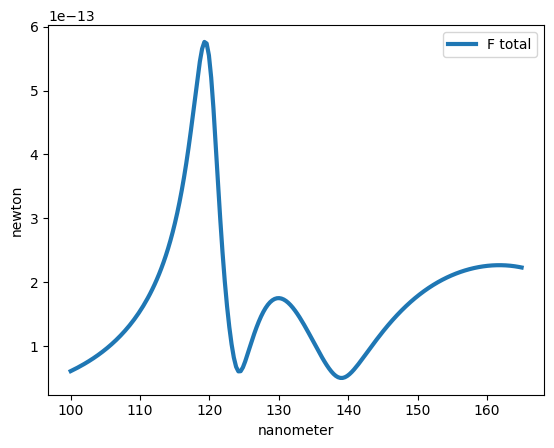

In [16]:
# plt.plot(Sorting_res.R, Sorting_res.Fx, label="Fx", lw=3)
# plt.plot(Sorting_res.R, Sorting_res.Fy, label="Fy", lw=3)
plt.plot(Sorting_res.R, np.sqrt(Sorting_res.Fx**2 + Sorting_res.Fy**2), label="F total", lw=3)
plt.legend()

NameError: name 'fx_fy_twobeam' is not defined

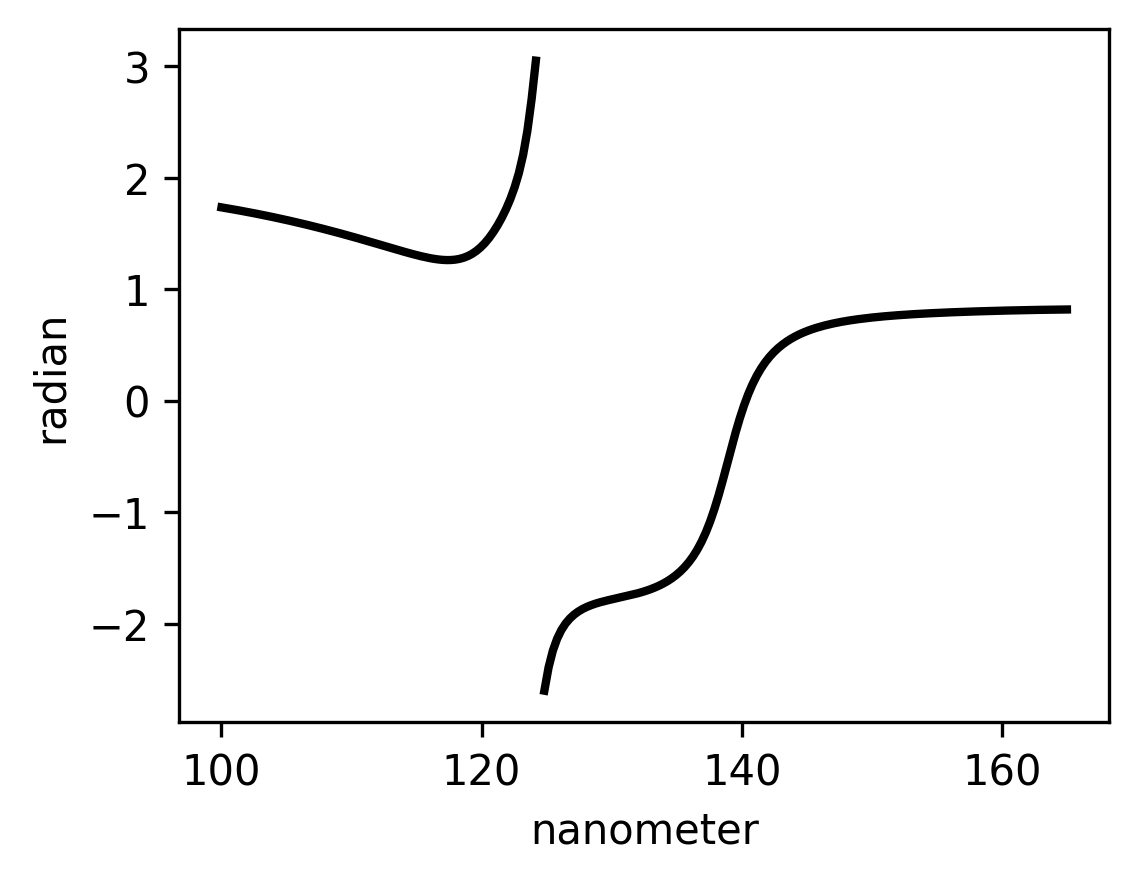

In [5]:
plt.figure(figsize=(4, 3), dpi=300)

phi_F = np.arctan2(Sorting_res.Fy, Sorting_res.Fx)

dphi = np.abs(np.diff(phi_F))
breaks = np.where(dphi > np.pi)[0]
phi_plot = phi_F.copy()
phi_plot[breaks + 1] = np.nan  # рвем линию

plt.plot(Sorting_res.R, phi_plot, lw=2, c='black', label=r'$\varphi(F)$')

phi_comsol = np.arctan2(fx_fy_twobeam[:,2],fx_fy_twobeam[:,1])

dphi_comsol = np.abs(np.diff(phi_comsol))
breaks_comsol = np.where(dphi_comsol > np.pi)[0]
phi_plot_comsol = phi_comsol.copy()
phi_plot_comsol[breaks_comsol + 1] = np.nan  # рвем линию


# plt.plot(fx_fy_twobeam[:,0], phi_plot_comsol , ls='-.', c='black', lw=2, label=r'Numerical' )


plt.xlabel('$R$ (nm)')
plt.ylabel(r'$\varphi(F)$ (rad)')

yticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
yticklabels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
plt.yticks(yticks, yticklabels)
plt.ylim(-np.pi, np.pi)

plt.xlim(Sorting_res.R.min().magnitude, Sorting_res.R.max().magnitude)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

#plt.savefig('article_plots/figure 4/phi_vs_R_two_beams.png', dpi=300)

plt.show()

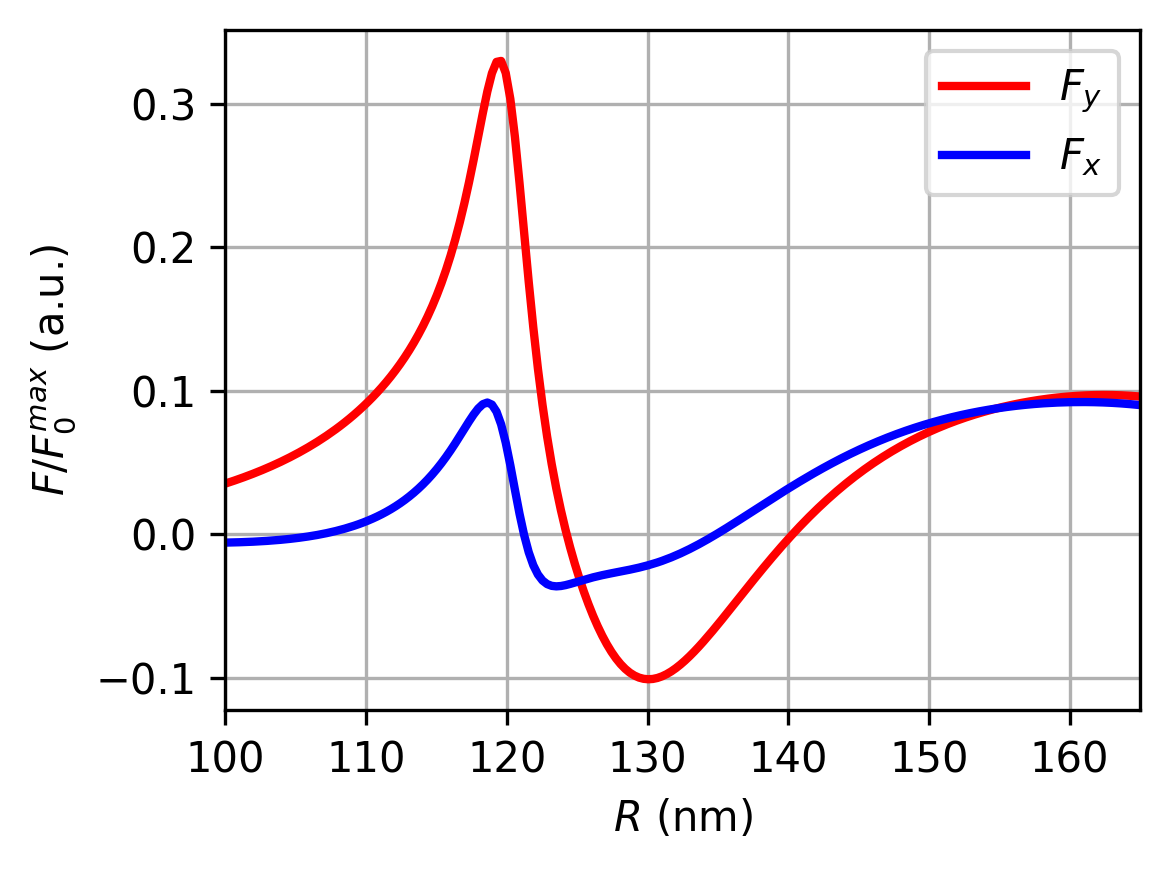

In [12]:
plt.figure(figsize=(4, 3), dpi=300)
plt.plot(Sorting_res.R.magnitude, Sorting_res.Fy.magnitude/F0, label='$F_y$', lw=2, c='red' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,1]/F0, label='$F_x$ (Numerical)', lw=2, c='blue', ls='--' )

# plt.plot(fx_fy_twobeam[:,0], fx_fy_twobeam[:,2]/F0, label='$F_y$ (Numerical)', lw=2, c='red', ls='--' )

plt.plot(Sorting_res.R.magnitude, Sorting_res.Fx.magnitude/F0, label='$F_x$', lw=2, c='blue')
plt.legend()
plt.xlabel('$R$ (nm)')
plt.ylabel('$F/F_0^{max}$ (a.u.)')
plt.grid()
plt.xlim(Sorting_res.R.min().magnitude, Sorting_res.R.max().magnitude)
plt.tight_layout()
#plt.savefig('article_plots/Fx_Fy_vs_R_two_beam_sorting.png', dpi=300)
plt.show()

In [11]:
base_config_free_space2 = SimulationConfig(
    wl = base_config.wl,
    R =  (295/2) * ureg.nanometer,
    dist = 2 * ureg.nanometer,
    angle = np.deg2rad(0),
    psi = 0,
    chi = 0,
    show_warnings=False,
    substrate = 'Air',
    initial_field_type='plane_wave',
)

setattr(base_config_free_space2, 'amplitude', E0.magnitude)

sweep_res_free_space2, _, _ = SweepRunner(base_config_free_space2, 'R', R_arr_sort, True, False, False, True, False).run()

F0arr = np.abs(sweep_res_free_space2['Fz'].magnitude)

F0 = np.max(F0arr)

  0%|          | 0/200 [00:00<?, ?it/s]

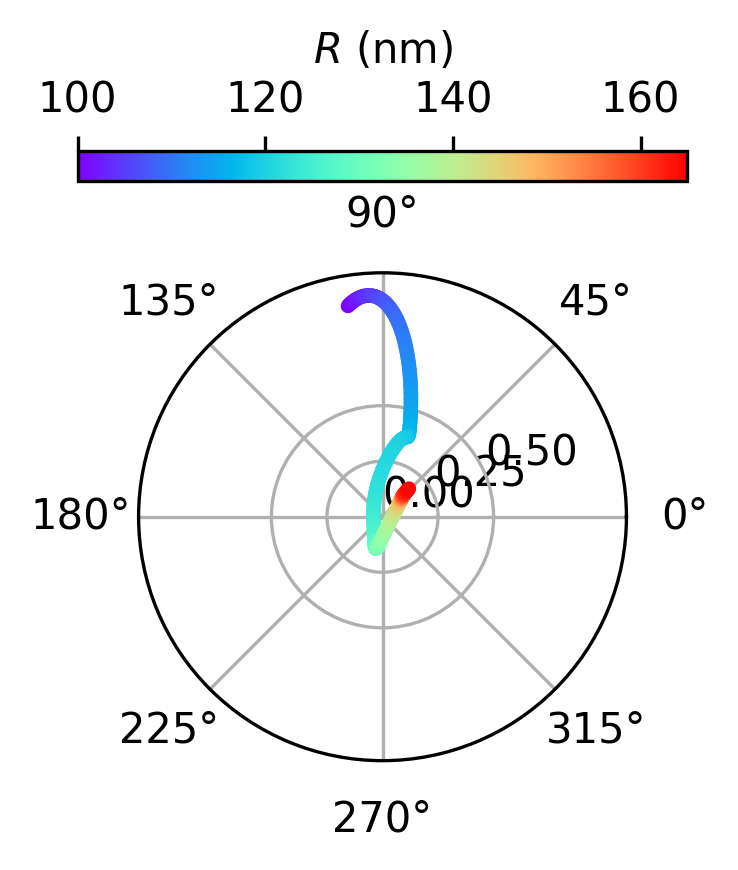

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

Fx = Sorting_res.Fx.magnitude
Fy = Sorting_res.Fy.magnitude
R  = Sorting_res.R.magnitude

phi = np.arctan2(Fy, Fx)
Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr



# --- подготовка сегментов для цветной линии ---
points = np.array([phi, Fabs]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=R.min(), vmax=R.max())

lc = LineCollection(
    segments,
    cmap='rainbow',
    norm=norm,
    linewidth=3.5,
    alpha=1.0,                 # ВАЖНО: без прозрачности
    antialiased=True,
    capstyle='round',          # скругление концов
    joinstyle='round'          # скругление соединений
)

lc.set_array(R[:-1])

# --- plot ---
fig = plt.figure(figsize=(3, 3), dpi=300)
ax = fig.add_subplot(111, projection='polar')

ax.add_collection(lc)

ax.set_theta_zero_location('E')   # Fx вправо
ax.set_theta_direction(1)
ax.set_thetamin(0)
ax.set_thetamax(360)

ax.set_ylim(0, np.nanmax(Fabs) * 1.1)
ax.set_yticks([0, 0.25, 0.5])

# --- colorbar ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation='horizontal',
    location='top',
    fraction=0.05,   # толщина
    pad=0.15          # расстояние от графика
)

cbar.set_label('$R$ (nm)')

plt.tight_layout()
# plt.savefig('article_plots/phi_F_polar_two_beam_sorting.png', dpi=300)
plt.show()

/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_65567/1010292609.py:79: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


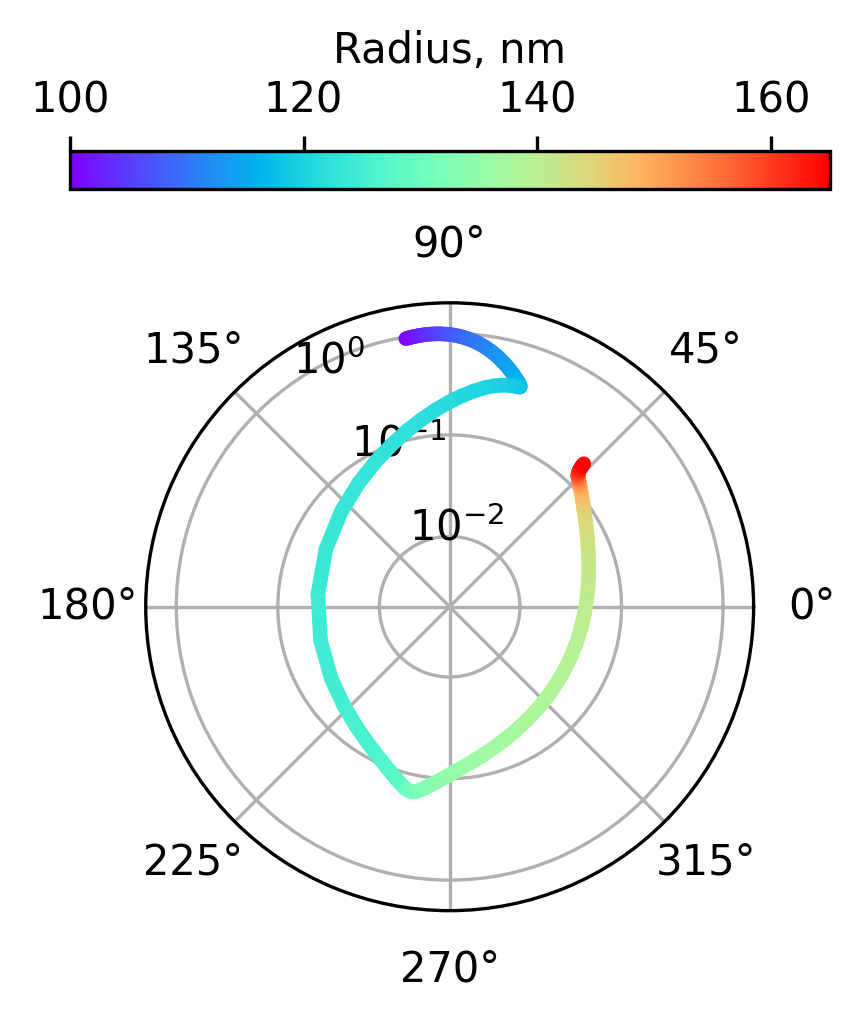

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['text.usetex'] = False

Fx = Sorting_res.Fx.magnitude
Fy = Sorting_res.Fy.magnitude
R  = Sorting_res.R.magnitude

Fxspp = Sorting_res.Fxspp.magnitude
Fyspp = Sorting_res.Fyspp.magnitude

Fx0 = Sorting_res.Fxe0.magnitude + Sorting_res.Fxm0.magnitude
Fy0 = Sorting_res.Fye0.magnitude + Sorting_res.Fym0.magnitude


phi = np.arctan2(Fy, Fx)
phi_spp = np.arctan2(Fyspp, Fxspp)
phi_0 = np.arctan2(Fy0, Fx0)

Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr
Fabs_spp = np.sqrt(Fxspp**2 + Fyspp**2) / F0arr
Fabs_0 = np.sqrt(Fx0**2 + Fy0**2) / F0arr

points = np.array([phi, Fabs]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=R.min(), vmax=R.max())

lc = LineCollection(
    segments,
    cmap="rainbow",
    norm=norm,
    linewidth=3.5,
    alpha=1.0,
    antialiased=True,
    capstyle="round",
    joinstyle="round"
)

lc.set_array(R[:-1])


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

# ax.set_ylim(1e-1, 1e1/4)  
# ax.set_ylim(0,2)
# ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])

# ax.set_ylim(0, Fabs.max() * 1.05)
# ax.set_yticks(0.25 * np.array([0,1,2]))
# ax.set_xlabel('varphi, rad')
# ax.set_ylabel('Radius, nm')
# ax.set_ylabel(r"$R$ (nm)", labelpad=25)

ax.set_rlabel_position(125)

# --- colorbar now shows force magnitude ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation="horizontal",
    location="top",
    fraction=0.05,
    pad=0.15
)

# ax.set_ylim(1e-1, 1e1*2)
ax.set_rscale("log")
ax.set_ylim(0, 2)
cbar.set_label("Radius, nm")

plt.tight_layout()
# plt.savefig("article_plots/figure 4/singleBeam_polar_sorting_raw_125_155.svg", dpi=300)
plt.show()

Text(0, 0.5, 'Fx (N)')

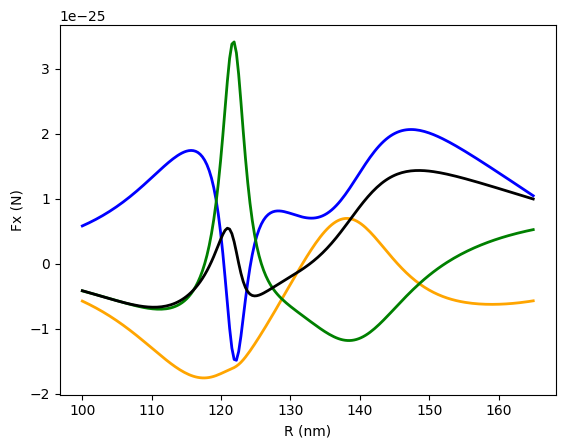

In [19]:
plt.plot(Sorting_res.R, Sorting_res.Fxe0+Sorting_res.Fxm0, label='Pressure', lw=2, c='blue')
plt.plot(Sorting_res.R, Sorting_res.Fxspp, label='SPP', lw=2, c='orange')
plt.plot(Sorting_res.R, Sorting_res.Fx - Sorting_res.Fxe0 - Sorting_res.Fxm0 - Sorting_res.Fxspp, label='Air', lw=2, c='green')
plt.plot(Sorting_res.R, Sorting_res.Fx, label='Total', lw=2, c='black')
plt.xlabel('R (nm)')
plt.ylabel('Fx (N)')

Text(0, 0.5, 'Fy (N)')

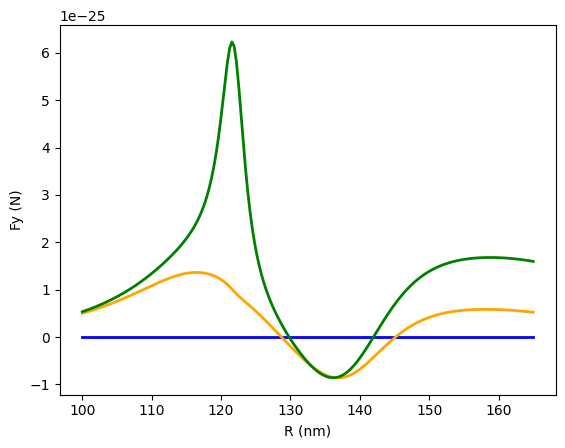

In [ ]:
plt.plot(Sorting_res.R, Sorting_res.Fye0+Sorting_res.Fym0, label='Pressure', lw=2, c='blue')
plt.plot(Sorting_res.R, Sorting_res.Fyspp, label='SPP', lw=2, c='orange')
plt.plot(Sorting_res.R, Sorting_res.Fy - Sorting_res.Fye0 - Sorting_res.Fym0 - Sorting_res.Fyspp, label='Air', lw=2, c='green')
plt.xlabel('R (nm)')
plt.ylabel('Fy (N)')

/var/folders/rm/jp69z42j5kv7gm1yn340dwx80000gn/T/ipykernel_93748/2592247937.py:66: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 2)


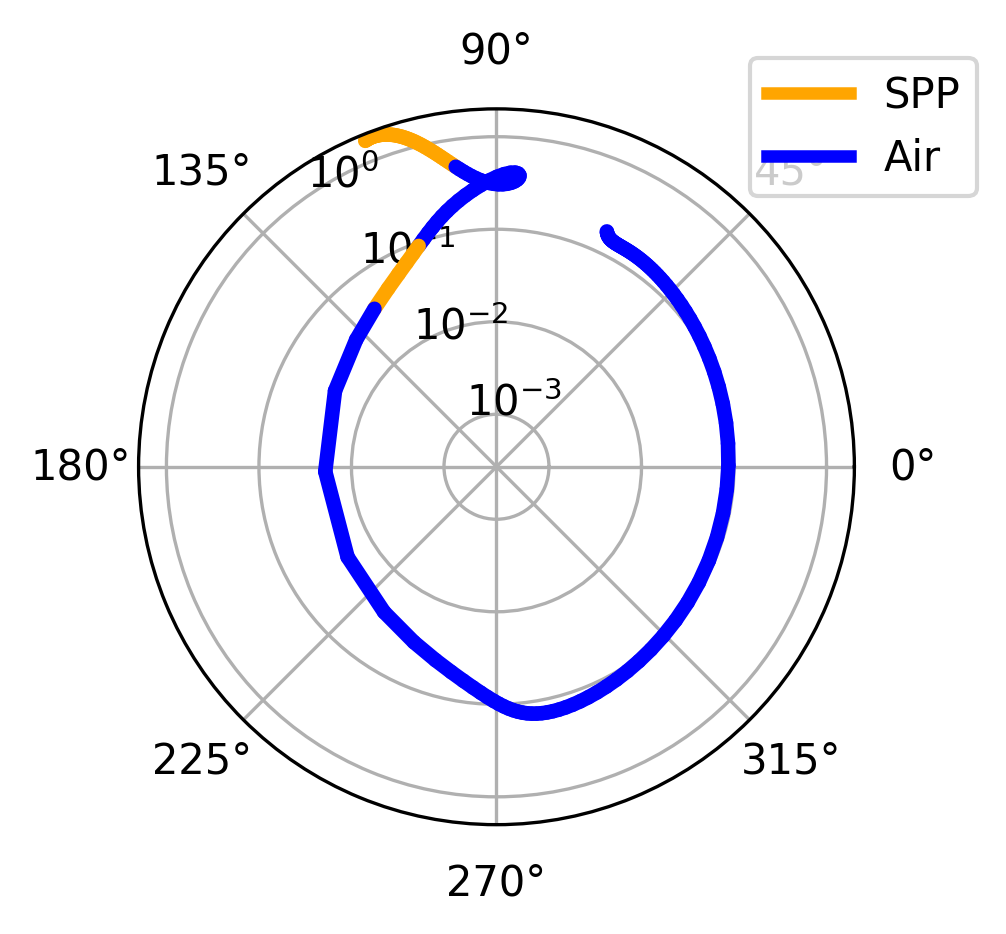

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --- forces ---
Fx = Sorting_res.Fx.magnitude
Fy = Sorting_res.Fy.magnitude
R  = Sorting_res.R.magnitude

Fxspp = Sorting_res.Fxspp.magnitude
Fyspp = Sorting_res.Fyspp.magnitude

Fx0 = Sorting_res.Fxe0.magnitude + Sorting_res.Fxm0.magnitude


# --- derived air contribution ---
Fx_air = Fx - Fx0 - Fxspp
Fy_air = Fy - Fyspp

# --- angles ---
phi = np.arctan2(Fy, Fx)

# --- magnitudes (normalized if needed) ---
Fabs     = np.sqrt(Fx**2 + Fy**2) / F0arr
Fabs_spp = np.sqrt(Fxspp**2 + Fyspp**2) / F0arr
Fabs_air = np.sqrt(Fx_air**2 + Fy_air**2) / F0arr

# --- determine dominant channel ---
# 0 = SPP, 1 = F0, 2 = air
stack = np.vstack([Fabs_spp, Fabs_air])
dominant = np.argmax(stack, axis=0)

# --- assign colors ---
color_map = {
    0: "orange",  # SPP
    1: "blue",    # F0
}
colors = np.array([color_map[i] for i in dominant])

# --- build segments ---
points = np.array([phi, Fabs]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# color per segment (use left point)
segment_colors = colors[:-1]

lc = LineCollection(
    segments,
    colors=segment_colors,
    linewidth=3.5,
    alpha=1.0,
    capstyle="round",
    joinstyle="round"
)

# --- plot ---
fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

ax.set_rscale("log")
ax.set_ylim(0, 2)
ax.set_rlabel_position(125)

# --- manual legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='orange', lw=3, label='SPP'),
    Line2D([0], [0], color='blue',   lw=3, label='Air'),
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

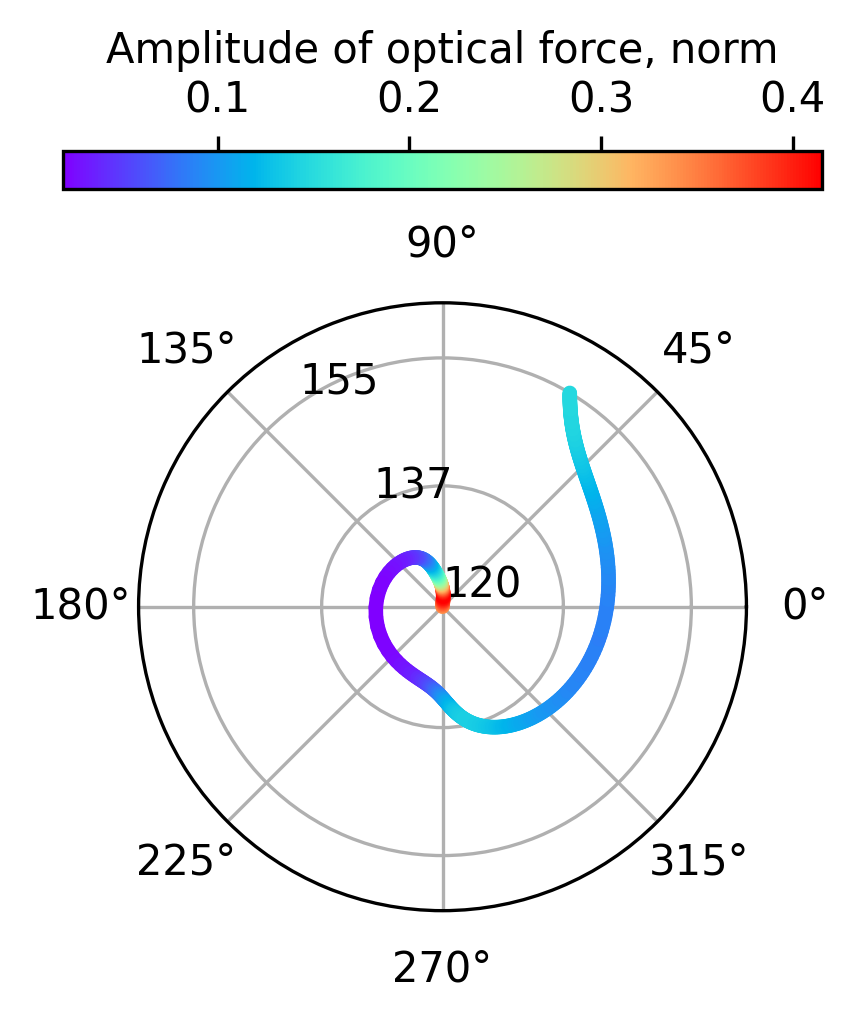

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

Fx = Sorting_res.Fx.magnitude
Fy = Sorting_res.Fy.magnitude
R  = Sorting_res.R.magnitude

phi = np.arctan2(Fy, Fx)

Fabs = np.sqrt(Fx**2 + Fy**2) / F0arr

points = np.array([phi, R]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=Fabs.min(), vmax=Fabs.max())

lc = LineCollection(
    segments,
    cmap="rainbow",
    norm=norm,
    linewidth=3.5,
    alpha=1.0,
    antialiased=True,
    capstyle="round",
    joinstyle="round"
)

lc.set_array(Fabs[:-1])


fig = plt.figure(figsize=(3.5, 3.5), dpi=300)
ax = fig.add_subplot(111, projection="polar")

ax.add_collection(lc)

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

ax.set_ylim(R.min(), R.max() * 1.05)
ax.set_yticks(np.linspace(R.min(), R.max(), 3, dtype=int))
# ax.set_xlabel('varphi, rad')
# ax.set_ylabel('Radius, nm')
# ax.set_ylabel(r"$R$ (nm)", labelpad=25)

ax.set_rlabel_position(125)

# --- colorbar now shows force magnitude ---
cbar = fig.colorbar(
    lc,
    ax=ax,
    orientation="horizontal",
    location="top",
    fraction=0.05,
    pad=0.15
)

cbar.set_label("Amplitude of optical force, norm")

plt.tight_layout()
plt.savefig("article_plots/figure 4/phi_R_polar_sorting_raw.svg", dpi=300)
plt.show()

Text(0, 0.5, '$F_x$')

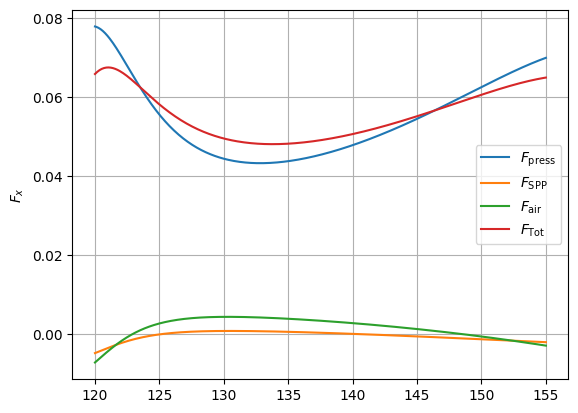

In [22]:
plt.plot(Sorting_res.R.magnitude, (Sorting_res.Fxe0 +Sorting_res.Fxm0) .magnitude/F0, label='$F_{\\text{press}}$')
plt.plot(Sorting_res.R.magnitude, Sorting_res.Fxspp.magnitude/F0, label='$F_{\\text{SPP}}$')
plt.plot(Sorting_res.R.magnitude, (Sorting_res.Fx - Sorting_res.Fxe0 -Sorting_res.Fxm0 -Sorting_res.Fxspp).magnitude/F0, label='$F_{\\text{air}}$')
plt.plot(Sorting_res.R.magnitude, Sorting_res.Fx.magnitude/F0, label='$F_{\\text{Tot}}$')
plt.grid()
plt.legend()
plt.ylabel('$F_x$')

Text(0, 0.5, '$F_y$')

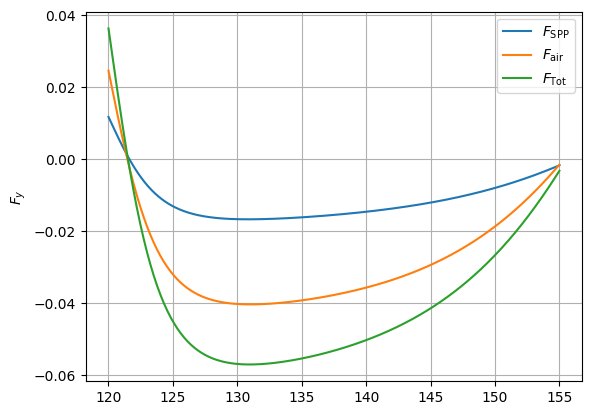

In [23]:
plt.plot(Sorting_res.R.magnitude, Sorting_res.Fyspp.magnitude/F0, label='$F_{\\text{SPP}}$')
plt.plot(Sorting_res.R.magnitude, (Sorting_res.Fy -Sorting_res.Fyspp).magnitude/F0, label='$F_{\\text{air}}$')
plt.plot(Sorting_res.R.magnitude, Sorting_res.Fy.magnitude/F0, label='$F_{\\text{Tot}}$')
plt.grid()
plt.legend()
plt.ylabel('$F_y$')

### Task

We have $R$ prticle and we want to approximate how fast that particle would go out of circle with radius $r$ under optical forces in free space above gold with resistance force (viscosity) of water. So from that we could understand how fast we need to change polarization parameters of system to mechanically manipulate a Si particle.


$$  m \frac{\partial^2 \vec{r}}{\partial t^2} = \vec{F}_{opt} - \nu \left( \frac{\partial \vec{r}}{\partial t} \right)^2$$